# Dataset of chemical and near-infrared spectroscopy measurements of fresh and dried poultry and cattle manure

## Description du dataset
Ce jeu de données est issus d'un échantillonage de 332 fumiers de volailles et de bovins provenant de differentes fermes dans les principales régions d'élévages en France métroplolitaine et sur l'île de la réunion. Ces échantillons ont été analysés sur 7 propriétés chimiques suivant les normes conventionnelles ISO et NF de laboratoire. Les données spectrales proches infrarouge (NIR) ont été acquises avec 3 spectromètres: le spectromètre XDS Foss du CIRAD comme référence, le spectromètre XDS Foss de ARVALIS et le spectromètre Buchi NIRFlex (LDAR). Les mésures spectrales ont été recueillis à partir d'échantillons frais homogènes dans un premier temps puis séchés et broyés dans un second, on a donc **2** enregistrements spectrales NIR de ces fumiers entre 1100–2498 nm. Puis ces données ont été normalisés à l'aide de l'algorithme PDS.\
les 7 composants chimiques analysés dans ces échantillons de fumiers sont:\
Dry matter **DM**, Total Ammonium **NH4**, Total Nitrogen **N**, phosphorus pentoxide **P2O5**, Calcium oxide **CaO**, Magnesium oxide **MgO**, potassium oxide **K2O**.\
Une description plus détaillée ainsi que l'intégralité des informations concernant ce projet sont transcrit dans l'article "1-s2.0-S2352340920315274-main-2.pdf" présent dans le github dont la DOI est la suivante: https://doi.org/10.1016/j.dib.2020.106647.

## Objectifs
Les objectifs de ce projet sont:
- Comprendre le mieux possible le jeu de données global(spectres NIR et propriétés) ainsi que la corrélation entre les composants chimiques du fumier.
- Construire un modèle de classification pour distaingué les fumiers de volaille et ceux de bovins
- Developper un modèle de prédiction pour les composés chimiques présents dans le fumier de volaille et de bovin.
- Developper une API à deployer pour la prédiction des propriétés en production 

## Importation des bibliothèques et du dataset

In [1]:
import numpy as np
import pandas as pd
from tkinter import filedialog
import matplotlib.pyplot as plt
import seaborn as sns
import tkinter as tk
import openpyxl as op
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from scipy import stats
try:
    import seaborn as sns
    sns.set(style="whitegrid")
except ImportError:
    sns=None

In [2]:
# Importation des propriétés chimiques ainsi que leurs provenances
prop = filedialog.askopenfilename(title="sélectionnez le fichier contenant les propriétés chimiques",  filetypes=[ ("Fichiers données", "*.xlsx *.csv *.xls *.CSV *.txt")])
df=pd.read_excel(prop, index_col="sample_name")
df.head()

,DM,NH4,N,CaO,K2O,MgO,P2O5,type_manure,spectrometer,township,country
sample_name,,,,,,,,,,,
FBCRIF001,20.815,0.075,0.490,NaN,NaN,NaN,NaN,cattle manure,NIRFlex LDAR,DERVAL,mainland France
FBCRIF002,25.480,0.182,0.607,0.157,0.791,0.079,0.131,cattle manure,NIRFlex LDAR,DERVAL,mainland France
FBCRIF003,17.595,0.203,0.546,0.208,0.690,0.094,0.160,cattle manure,NIRFlex LDAR,DERVAL,mainland France
FBCRIF004,19.110,0.091,0.482,0.260,0.542,0.121,0.187,cattle manure,NIRFlex LDAR,CHATEAUNEUF DU FAOU,mainland France
FBCRIF005,18.600,0.089,0.458,NaN,NaN,NaN,NaN,cattle manure,NIRFlex LDAR,CHATEAUNEUF DU FAOU,mainland France


In [3]:
#importation des spectres NIR
spectrum1 = filedialog.askopenfilename(title="sélectionnez les données spectrales NIR pour le fumier frais homogène ",  filetypes=[ ("Fichiers données", "*.xlsx *.csv *.xls *.CSV *.txt")])
spectrum2 = filedialog.askopenfilename(title="sélectionnez les données spectrales NIR pour le fumier sec et broyé",  filetypes=[ ("Fichiers données", "*.xlsx *.csv *.xls *.CSV *.txt")])

In [4]:
df_FH=pd.read_excel(spectrum1, index_col="sample_name") #fumier frais et homogène
df_DG=pd.read_excel(spectrum2, index_col="sample_name") #fumier sec et broyé
df_FH.head()

,1100_nm,1102_nm,1104_nm,1106_nm,1108_nm,1110_nm,1112_nm,1114_nm,1116_nm,1118_nm,...,2480_nm,2482_nm,2484_nm,2486_nm,2488_nm,2490_nm,2492_nm,2494_nm,2496_nm,2498_nm
sample_name,,,,,,,,,,,,,,,,,,,,,
FBCRIF001,0.588418,0.588407,0.588012,0.587727,0.587602,0.587279,0.586653,0.586186,0.586046,0.585861,...,1.684603,1.686953,1.689275,1.691759,1.694338,1.696744,1.698854,1.700564,1.701765,1.702570
FBCRIF002,0.530671,0.530607,0.530356,0.530160,0.530084,0.529749,0.529146,0.528818,0.528807,0.528645,...,1.576865,1.579084,1.581248,1.583488,1.585777,1.587941,1.589935,1.591674,1.593029,1.594062
FBCRIF003,0.532509,0.532652,0.532556,0.532679,0.532500,0.532282,0.531813,0.531593,0.531658,0.531550,...,1.610761,1.612479,1.614203,1.616133,1.618259,1.620364,1.622323,1.623984,1.625191,1.626028
FBCRIF004,0.495200,0.494887,0.494335,0.493886,0.493594,0.493283,0.492497,0.492086,0.492000,0.491789,...,1.566656,1.568502,1.570339,1.572338,1.574459,1.576464,1.578253,1.579747,1.580875,1.581749
FBCRIF005,0.476230,0.476494,0.476465,0.476356,0.476468,0.476366,0.476144,0.476265,0.476501,0.476709,...,1.601588,1.603243,1.604913,1.606800,1.608894,1.610958,1.612836,1.614357,1.615386,1.616054


In [5]:
df_fh = pd.merge(df, df_FH, how="right", on="sample_name")
df_dg = pd.merge(df, df_DG, how="right", on="sample_name")
df_dg.head()

,DM,NH4,N,CaO,K2O,MgO,P2O5,type_manure,spectrometer,township,...,2480_nm,2482_nm,2484_nm,2486_nm,2488_nm,2490_nm,2492_nm,2494_nm,2496_nm,2498_nm
sample_name,,,,,,,,,,,,,,,,,,,,,
FBCRIF001,20.815,0.075,0.490,NaN,NaN,NaN,NaN,cattle manure,NIRFlex LDAR,DERVAL,...,0.352863,0.354768,0.356484,0.357876,0.359046,0.359973,0.360660,0.361052,0.361174,0.361169
FBCRIF002,25.480,0.182,0.607,0.157,0.791,0.079,0.131,cattle manure,NIRFlex LDAR,DERVAL,...,0.362040,0.364098,0.365936,0.367408,0.368604,0.369494,0.370083,0.370328,0.370269,0.370059
FBCRIF003,17.595,0.203,0.546,0.208,0.690,0.094,0.160,cattle manure,NIRFlex LDAR,DERVAL,...,0.380576,0.382347,0.383936,0.385200,0.386232,0.387005,0.387527,0.387755,0.387724,0.387581
FBCRIF004,19.110,0.091,0.482,0.260,0.542,0.121,0.187,cattle manure,NIRFlex LDAR,CHATEAUNEUF DU FAOU,...,0.370933,0.372936,0.374728,0.376168,0.377350,0.378252,0.378879,0.379182,0.379185,0.379029
FBCRIF005,18.600,0.089,0.458,NaN,NaN,NaN,NaN,cattle manure,NIRFlex LDAR,CHATEAUNEUF DU FAOU,...,0.361757,0.363635,0.365298,0.366606,0.367655,0.368422,0.368911,0.369075,0.368951,0.368688


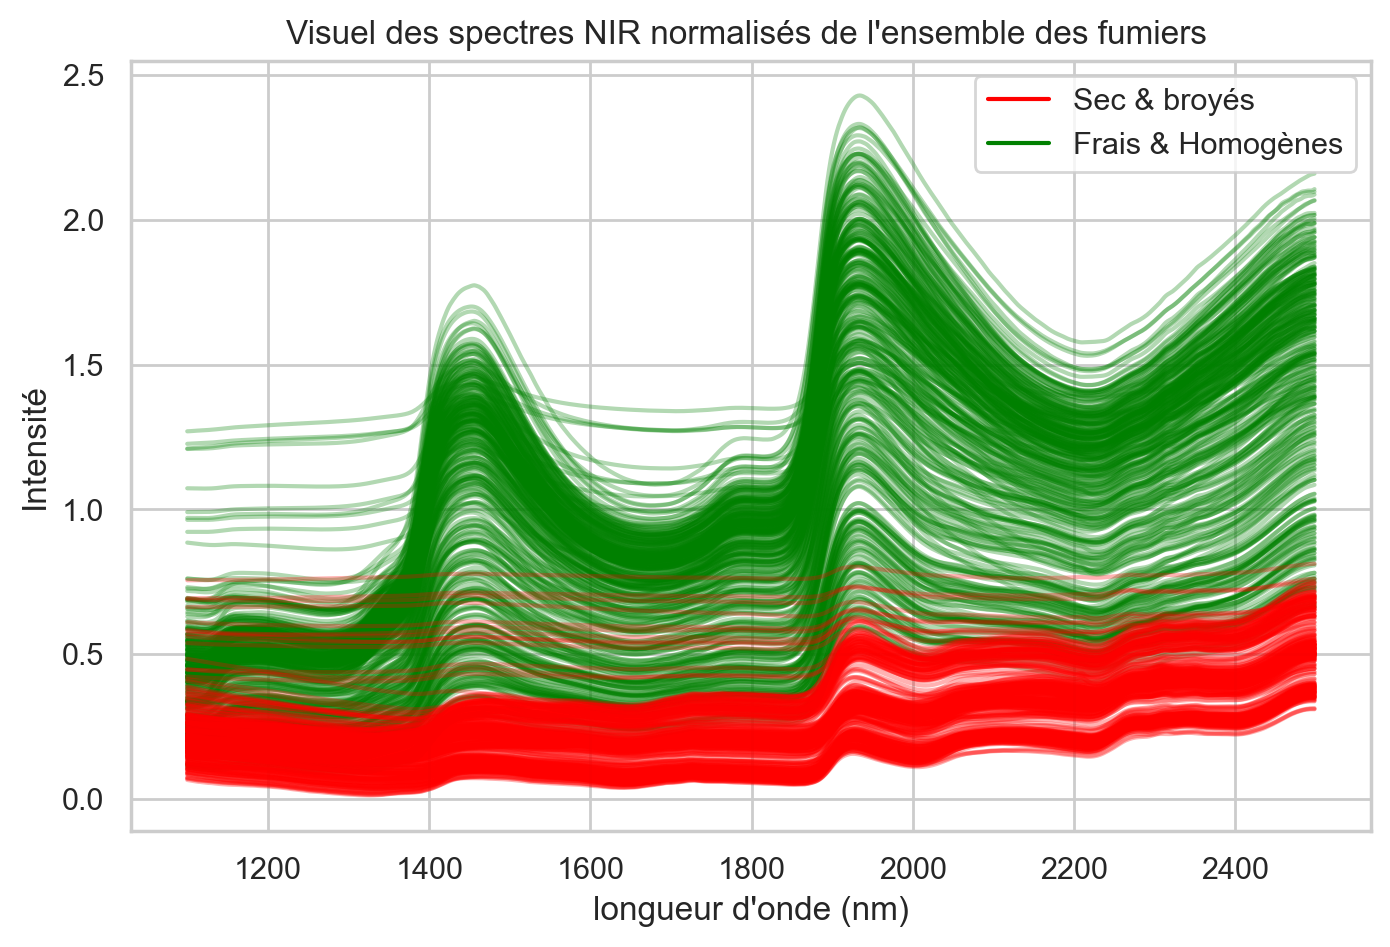

In [6]:
# l’axe X doit correspondre au nombre de colonnes du DataFrame

n_points = df_FH.shape[1]
x = np.linspace(1100, 2498, n_points) #nombre de points identique pour DG et FH

plt.figure(figsize=(8, 5), dpi=200)

# tracer chaque ligne (chaque spectre)
# Plot des spectres FH
for i in range(df_FH.shape[0]):              
    y = df_FH.iloc[i, :].astype(float).values  
    plt.plot(x,y, alpha=0.3,color="green") 

# Plot des spectres DG 
for i in range(df_DG.shape[0]):              
    y_DG = df_DG.iloc[i, :].astype(float).values  
    plt.plot(x, y_DG, alpha=0.3, color="red" )

    
plt.xlabel("longueur d'onde (nm)")    
plt.ylabel("Intensité")
plt.title("Visuel des spectres NIR normalisés de l'ensemble des fumiers ")
plt.plot([], [], color="red", label="Sec & broyés") #Ajout de 2 lignes fictives pour afficher les légendes
plt.plot([], [], color="green", label="Frais & Homogènes")
plt.legend()
plt.grid(True)
plt.show()

# Analyse exploratoire des données (EDA)
### Analyse de forme
- **Variable target** : type_manure
- **Nombre de ligne** : 332
- **Nombre de colonne** : 700 colonnes pour chacun des deux jeux de données spectrales + 11 colonnes pour les differentes propriétés et attributs des échantillons.
- **Type de variable** : 699 variables spectrales allant de 1100 à 2498 nm avec un pas régulier de 2 nm, 7 variables quantitatives continues, 4 variables qualitatives nominales.
- **Analyse des valeurs manquantes** : les variables CaO , K2O, MgO et P2O5 ne comptent que 158/332 lignes dû au faite que seulement 158 échantillons ont été analysés.

In [7]:
print(df_DG.shape , df_FH.shape , df.shape )

(332, 700) (332, 700) (332, 11)


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 332 entries, FBCRIF001 to R_FERM_90_FBV_LT
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   DM            332 non-null    float64
 1   NH4           332 non-null    float64
 2   N             332 non-null    float64
 3   CaO           158 non-null    float64
 4   K2O           158 non-null    float64
 5   MgO           158 non-null    float64
 6   P2O5          158 non-null    float64
 7   type_manure   332 non-null    object 
 8   spectrometer  332 non-null    object 
 9   township      332 non-null    object 
 10  country       332 non-null    object 
dtypes: float64(7), object(4)
memory usage: 31.1+ KB


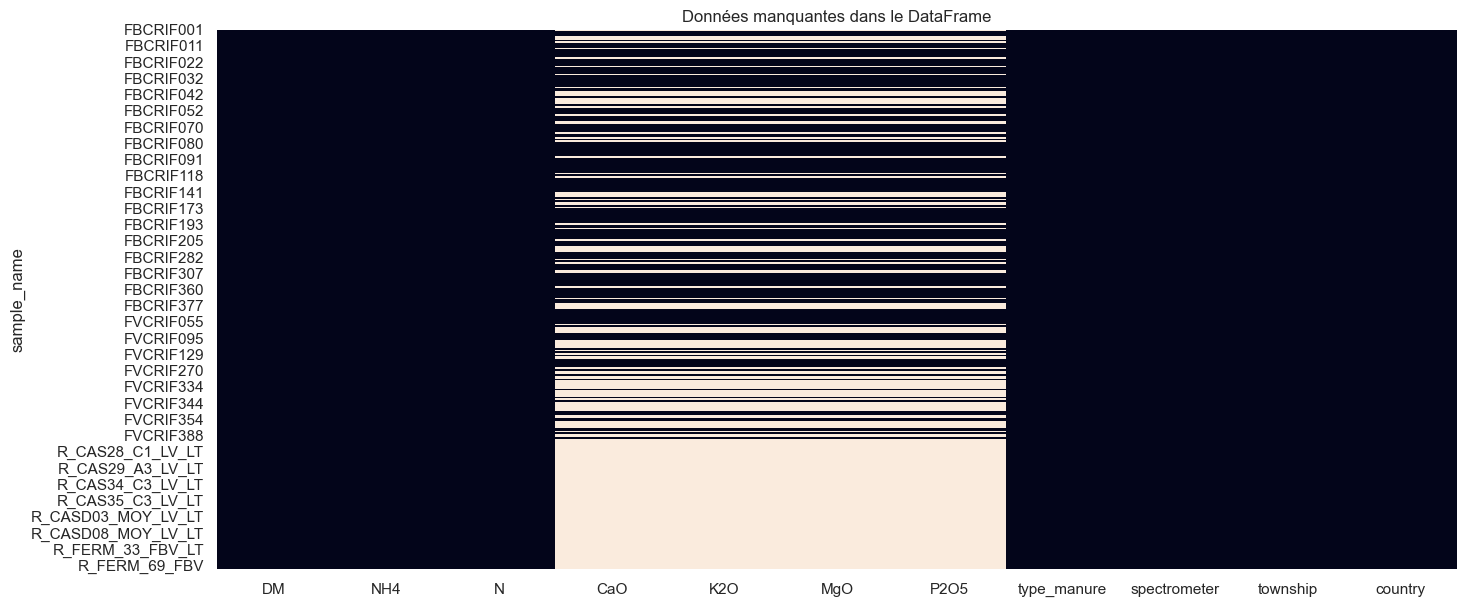

In [9]:
#les données manquantes
plt.figure(figsize=(16,7))
sns.heatmap(df.isna(), cbar=False)
plt.title("Données manquantes dans le DataFrame")
plt.show()

## Analyse de Fond

### Analyse univariée des variables quantitatives

In [10]:
df.describe()

,DM,NH4,N,CaO,K2O,MgO,P2O5
count,332.000000,332.000000,332.000000,158.000000,158.000000,158.000000,158.000000
mean,37.285322,0.262431,1.369367,0.574911,1.022418,0.226601,0.476652
std,20.063330,0.276476,1.092611,0.556341,0.647886,0.186200,0.585072
min,11.255000,0.001000,0.255000,0.094000,0.187000,0.062000,0.091000
25%,20.103750,0.038000,0.474750,0.226000,0.584750,0.112000,0.164500
50%,27.885000,0.095000,0.672000,0.330000,0.825500,0.155500,0.223500
75%,53.653750,0.505500,2.432250,0.697000,1.223000,0.238750,0.364000
max,82.480000,1.086000,4.152000,3.108000,3.845000,1.054000,3.020000


**Mésure de tendance centrale** - **Mésure de la dispersion** - **Quantiles** 

1. *DM*: Il est l'élement le plus plus abondant de la composition chimique des fumiers vu qu'il est issus du fumier frais dépourvu de son activité en eau. Avec une moyenne de 37.29 et une médianne de 27.89 soit une différence ~10 unités, on observe une asymétrie à droite(Queu à droite) pour le taux de matière sèche. A celà il faut notifier qu'en moyenne 50% des fumiers contiennent moins de 27.89% de matière sèche et 50% en contiennent plus de de 27.89%. Aussi 75% des fumiers ont moins de 53.65% de matière sèche donc 25% de matières sèches ont entre 53.65% et 82.48%. Avec un écart-type de 20.06 l'ensemble de nos fumiers présente une variablité plutôt faible en matière sèche.


3. *NH4* :les fumiers ont en moyenne moins de 0.5% d'ammonium dans leurs compositions, l'ammonium est l'un des élements les moins abondant dans cette composition chimique.
4. *N* : l'azote à une moyenne
5. *CaO* : l'oxyde de calcium
6. *K2O* :l'oxyde de potassium
7. *MgO* : l'oxyde de magnésium
8. *P2O5* : le pentaoxyde de phosphore

### Création de sous-ensemble
- 1 sous ensemble pour les fumiers de bovins(cattle) et un sous ensemble pour les fumiers de volailles (poultry)

In [11]:
cattle_manure = df[df['type_manure'] == 'cattle manure']
poultry_manure = df[df['type_manure'] == 'poultry manure']
cattle = pd.concat([ df_fh[df_fh['type_manure'] == 'cattle manure'], df_dg[df_dg['type_manure'] == 'cattle manure'] ], ignore_index=True)
poultry = pd.concat([ df_fh[df_fh['type_manure'] == 'cattle manure'],df_dg[df_dg['type_manure'] == 'poultry manure'] ], ignore_index=True)
Quant = ["DM", "NH4", "N", "CaO", "K2O", "MgO", "P2O5"]
Quant_2 = ["NH4", "N", "CaO", "K2O", "MgO", "P2O5"]

### Visualisations (histogramme, KDE, boxplot)

les graphiques permettent de voir la distribution:
- Histogramme: fréquence des valeurs dans des classes
- KDE(kernel density estimation): estimation lissée de la densité
- Boxplot: résumé visuel (médiane, quartiles, outliers)
#### Histogrammes

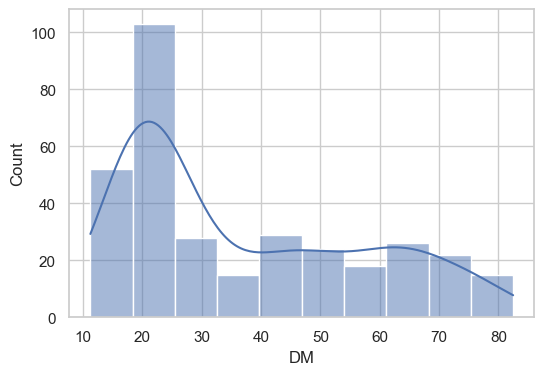

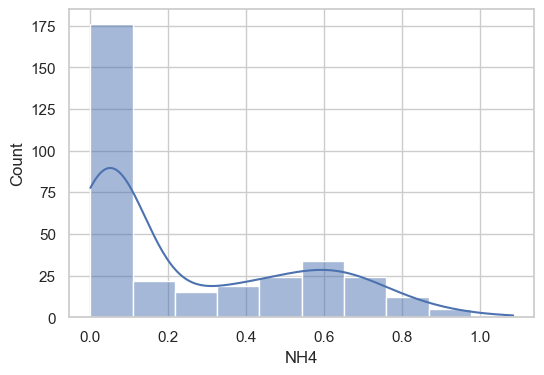

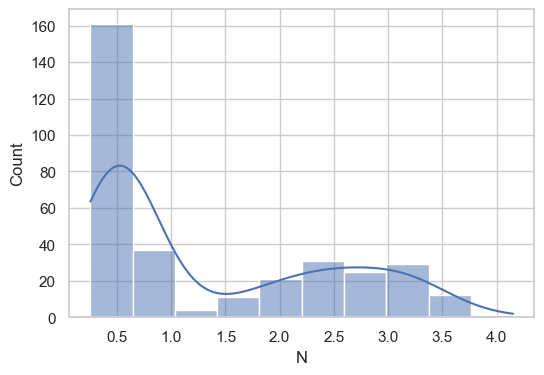

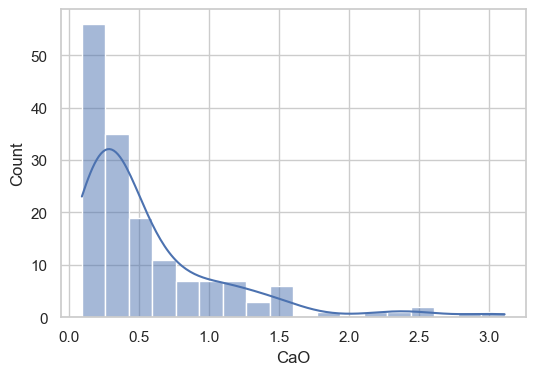

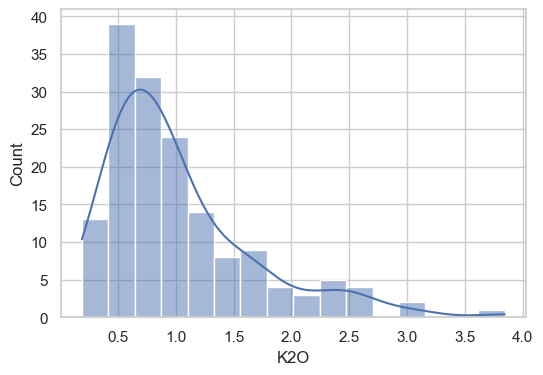

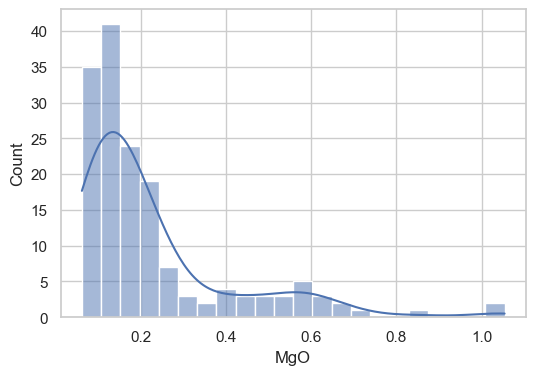

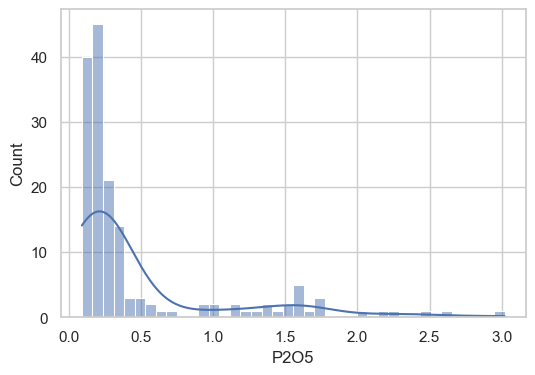

In [12]:
for col in df.select_dtypes('float'):
 plt.figure(figsize=(6, 4))
 sns.histplot(df[col], kde=True)

**Interprétation rapide**\
Ces histogrammes des composants chimiques presents dans les fumiers nous presentent visuellement une distribution anormale pour chaque composant chimique et cela sans faire d'analyse statististique supplémentaire. Cela est due au mélange des deux types de fumiers à savoir celui du bovin et celui de volaille qui ont des caractéristiques très différents. Nous allons observé la distribution pour chaque fumier séparement et les analyser.

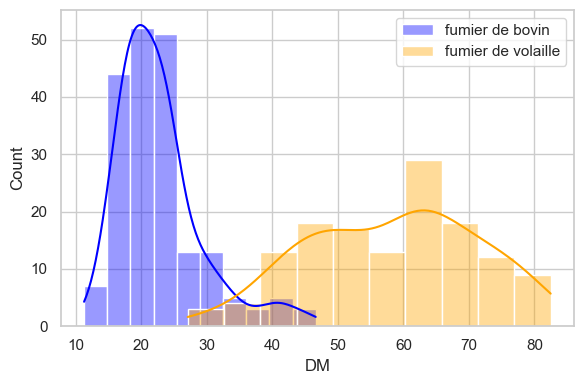

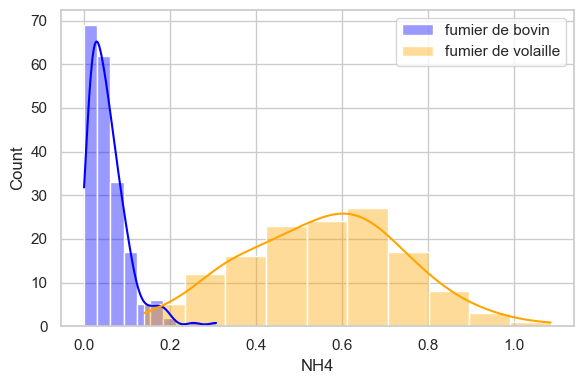

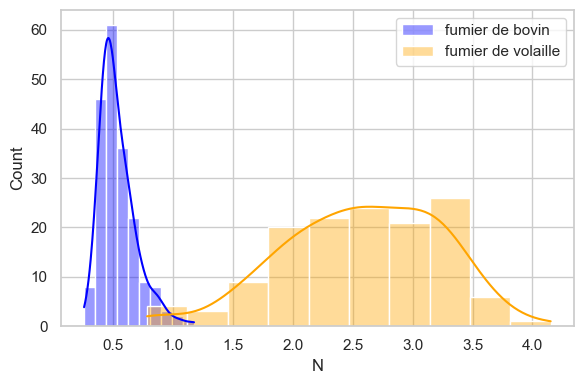

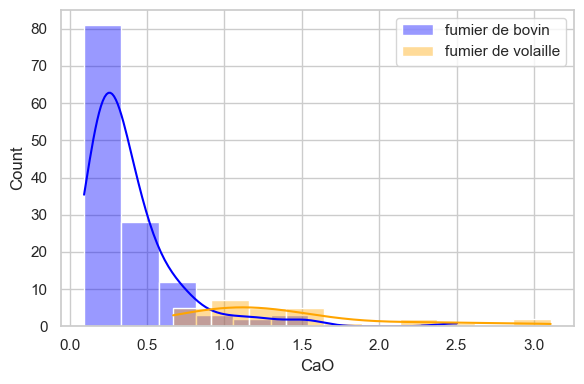

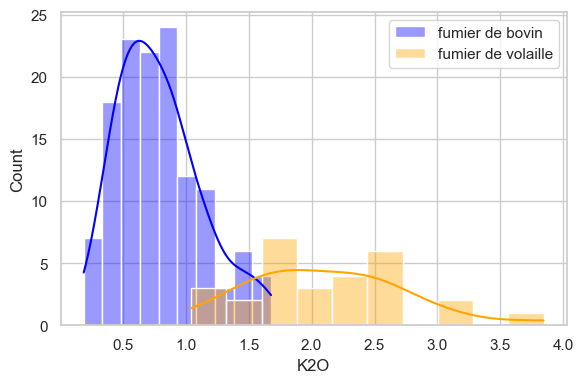

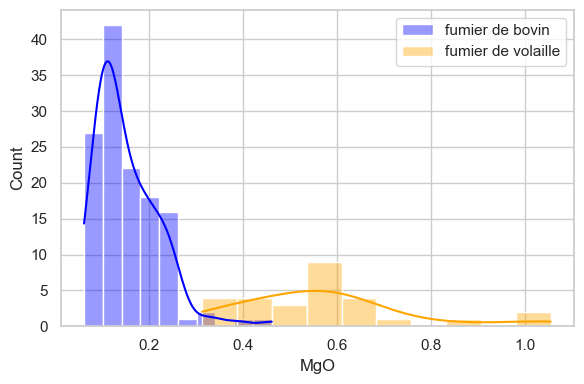

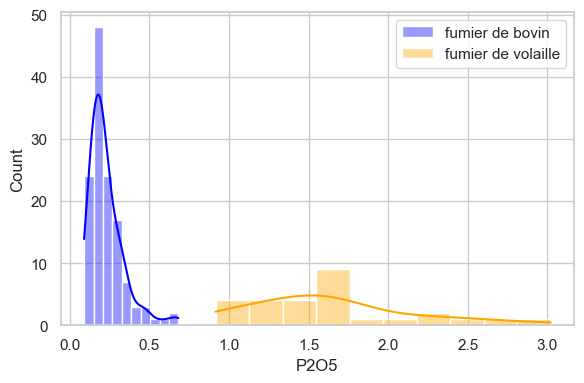

In [13]:
#Histogramme des composants chimiques en fonction du type de fumier
for col in df.select_dtypes('float'):
    plt.figure(figsize=(6, 4))

    sns.histplot(
        cattle_manure[col].dropna(),
        bins=10,
        stat="count",
        color="blue",
        alpha=0.4,
        kde=True,
        label="fumier de bovin"
    )

    sns.histplot(
        poultry_manure[col].dropna(),
        bins=10,
        stat="count",
        color="orange",
        alpha=0.4,
        kde=True,
        label="fumier de volaille"
    )

    plt.legend()
    plt.tight_layout()
    plt.show()

**Observations**\
On peut observer un écart considérable entre la distribution des fumiers de bovins et ceux de volailles pour chaque composant chimique. Les fumiers de bovins ont des concentrations plus faible avec une dispersion plus faible donc un concentré d'échantillons dans la même gamme de concentration (pic de concentration) pour chaque composant chimique. Quant aux fumiers de volailles, ils ont des concentrations plus élevés que les fumiers de bovins tout en ayant une dispersion plus grande donc des échantillons moins concentrés dans la gamme et celà pour tout les composants chimiques.

In [14]:
from scipy.stats import *

X= df[Quant]
results = []
for var in X:
    x = X[var].dropna()
    stat, p = shapiro(x)
    normality = 'Normal' if p > 0.05 else 'Not Normal'
    results.append({
        'Variable': var,
        'P-value': p,
        'Normality': normality
    })

normality_df = pd.DataFrame(results)

print(normality_df)


  Variable       P-value   Normality
0       DM  8.034462e-16  Not Normal
1      NH4  6.125466e-19  Not Normal
2        N  1.124451e-19  Not Normal
3      CaO  1.045450e-15  Not Normal
4      K2O  2.514298e-11  Not Normal
5      MgO  1.752976e-15  Not Normal
6     P2O5  1.970218e-18  Not Normal


Cette étude de la normalité de la distribution des différentes propriétés chimiques du fumier se conclut par une distribution non  normal pour chaque propriété. Cela va nous emmener à choisir des tests statistiques non paramétriques pour l'étude ultérieur des données.

#### Boxplots

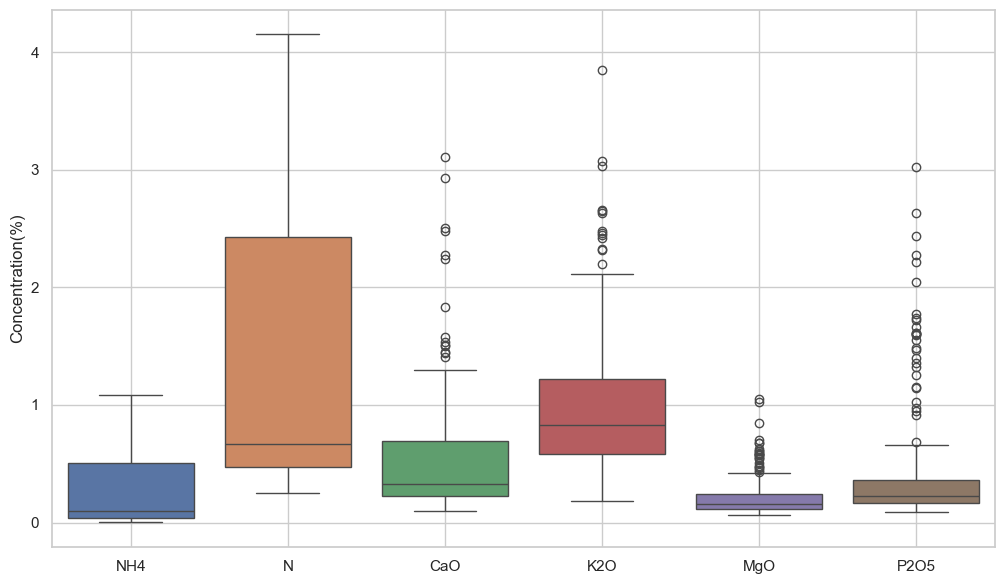

In [15]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10,6))
sns.boxplot(data=df[Quant_2])

plt.grid(True)
plt.tight_layout()
plt.ylabel("Concentration(%)")
plt.show()

**Interprétation**

La distribution des composants chimiques des fumiers est fortement impacté par les différents types de fumiers présent.\
L'azote est le composé chimique à la distribution la plus large car intervalle interquartile le plus grand parmis les composants chimiques, avec une médiane basse due à la concentration faible des fumiers de bovins contrairement au fumiers de volailles qui ont une grande dispersion et une concentration plus élévé.

Pour l'ensemble des 6 composants chimiques la médiane est basse due à la différence entre les concentrations des fumiers de volailles et de bovins, cela couplé à de longues moustaches supérieurs on aboutit à une asymétrie à droite pour chaque distribution.

En se concentrant sur les composants chimiques CaO, K2O, MgO et P2O5, les différences de concentrations donc des variabilités sont plus prononcés car beaucoups d'outliers sont observés en dehors de l'intervalle interquartile (Q3-Q1).

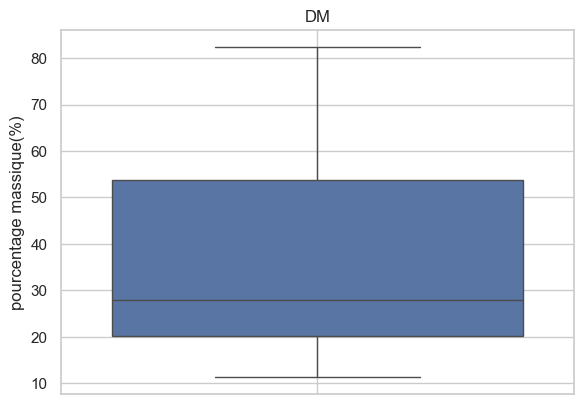

In [16]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(6,4))
sns.boxplot(data=df["DM"])

plt.grid(True)
plt.tight_layout()
plt.title("DM")
plt.ylabel("pourcentage massique(%)")
plt.show()

### Analyse univarié Qualitative

In [17]:
for col in df.select_dtypes('object'):
    print(f'{col:-<50} {df[col].unique()}')

type_manure--------------------------------------- ['cattle manure' 'poultry manure']
spectrometer-------------------------------------- ['NIRFlex LDAR' 'XDS FOSS ARVALIS' 'XDS FOSS CIRAD']
township------------------------------------------ ['DERVAL' 'CHATEAUNEUF DU FAOU' "THORIGNE D'ANJOU" 'MONTREUIL SUR LOIRE'
 'LE RHEU' 'GROUGIS' 'DRAVEGNY' 'PLOUMAGAOR' 'PLOUFRAGAN' 'SAINT PEVER'
 'PLAINE-HAUTE' 'BOURBRIAC' 'SAINT DOWAN' 'CAODOUT' 'PLUSQUELLEC'
 'SAINT NICOLAS DU PELEM' 'SION LES MINES' 'MARTIGUE SUR MAYENNE'
 "PLOEUC L'HERMITAGE" 'COEX' 'SAINT HILAIRE DE LOULOY'
 'LE CHAMP SUR LAYOU' 'LANRIVAIN' 'PLOUNEVEZ-QUINTIN' 'PLOUAGAT'
 'SAINT DONAN' 'MONTOLDRE' 'MOULINS' 'CRECHY' 'LANRODEC' 'BEGARD'
 'LE FOEIL' 'MOHAN' 'LANTILLAC' 'BIGNAN' 'MOHON' 'MOREAC'
 'SAINT HILAIRE LES LOGES' 'FARSSAIS-PAYE' 'RADENAC' 'PLELO'
 'PLEUMEUR-BODOU' 'CALLAC' 'PLOSQUELLEC' 'LANFAINS' 'PLOERMEL' 'PENGUILY'
 'SAINT CARREUC' 'INGRANNES' 'VIEILLES-MAISONS' 'LORRIS'
 'CHILLEURS AUX BOIS' 'CHATEAUNEUF SUR LOIRE' 

In [18]:
Quali= ["type_manure", "spectrometer","country"]
serie_quali = df[Quali].astype("category")
effectifs = serie_quali.value_counts()
effectifs

type_manure     spectrometer      country        
cattle manure   NIRFlex LDAR      mainland France    107
                XDS FOSS ARVALIS  mainland France     73
poultry manure  XDS FOSS CIRAD    Reunion Island      64
                NIRFlex LDAR      mainland France     49
                XDS FOSS ARVALIS  mainland France     23
cattle manure   XDS FOSS CIRAD    Reunion Island      16
Name: count, dtype: int64

In [19]:
proportions = serie_quali.value_counts(normalize=True) *100
proportions.round(2)

type_manure     spectrometer      country        
cattle manure   NIRFlex LDAR      mainland France    32.23
                XDS FOSS ARVALIS  mainland France    21.99
poultry manure  XDS FOSS CIRAD    Reunion Island     19.28
                NIRFlex LDAR      mainland France    14.76
                XDS FOSS ARVALIS  mainland France     6.93
cattle manure   XDS FOSS CIRAD    Reunion Island      4.82
Name: proportion, dtype: float64

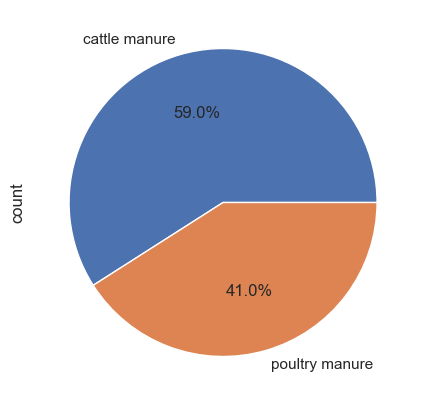

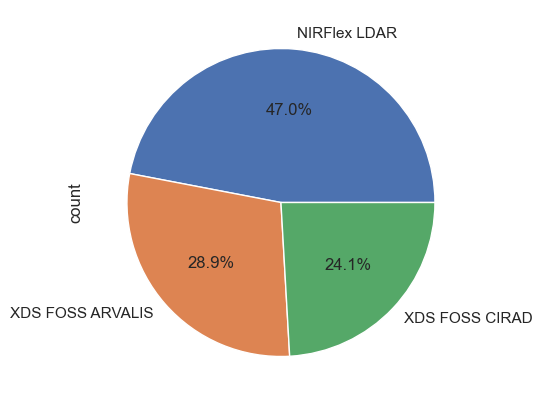

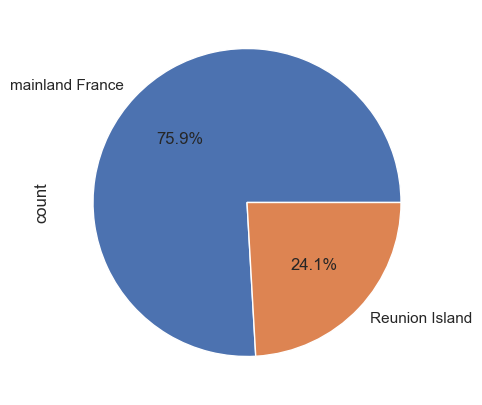

In [20]:
for col in df[Quali]:
    plt.figure(figsize=(8,5))
    df[col].value_counts().plot.pie( autopct="%1.1f%%")

#### Analyse

- Environ 6 échantillons sur 10 de fumiers recueillis sont d'origine bovine et les 4/10 restantes sont des fumiers de volailles.
- Presque la moitié des analyses spectrales ont été effectué sur des spectromètres NIRFlex LDAR, quant aux deux autres spectromètres (XDS ARVALIS et XDS CIRAD) ils ont effectué environ 1/4 des analyses spectrales chacun.
- 3/4 des fumiers utlisés dans ce jeu de données proviennent de France métropolitaine et les 1/4 restants de l'île de la réunion.

### Analyse bivarié
#### 1. Evaluation de la corrélation entre les variables quantitative - quantitative

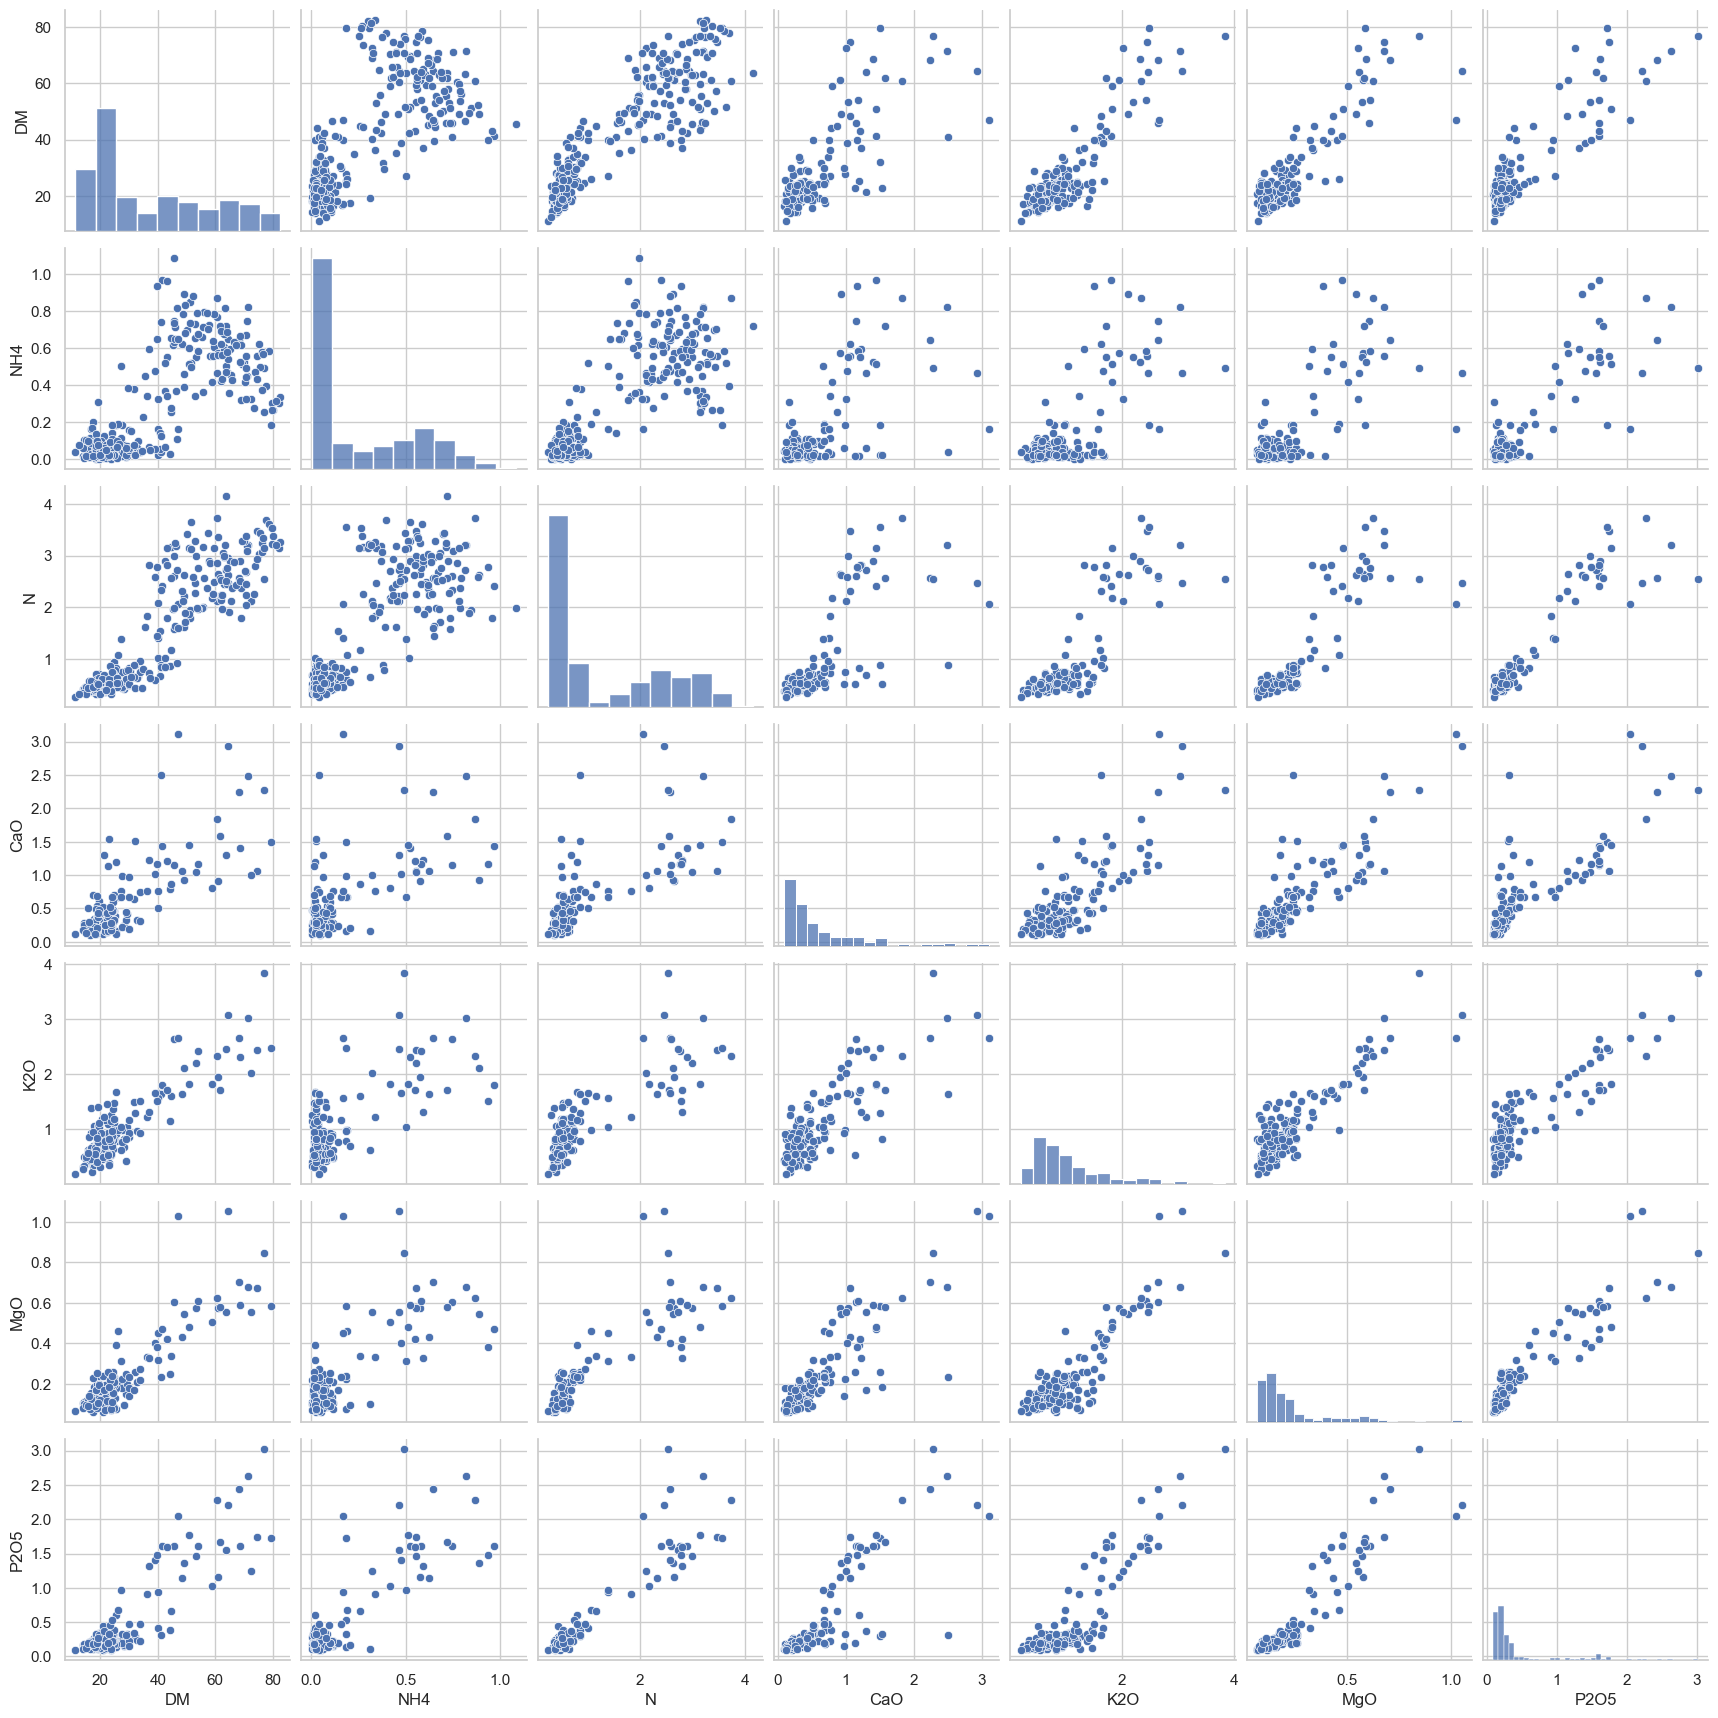

In [21]:
sns.pairplot(df[Quant])

<Axes: >

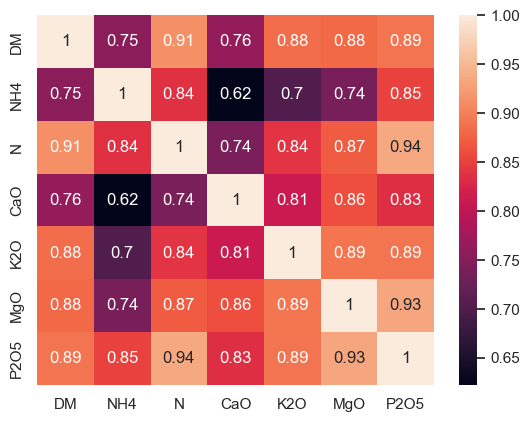

In [22]:
sns.heatmap(df[Quant].corr(), annot=True)

**Analyse**
- A partir du pairplot on a pu observer sur les nuages de points des tendances de corrélation linéaire simultanément entre les composants DM, P2O5, K2O et MgO.
- A partir de la heatmap nous avons quantifié ces corrélations linéaire, il s'avère que l'azote à une forte corrélation linéaire positive avec P2O5 (0.94) ainsi qu'avec DM (0.91).
- les observations sur le pairplot ont été confirmés avec la heatmap.
- On a globalement une corrélation positive suppérieur à 0.6 pour chaque composant chimique, avec les composants CaO et NH4 ayant les corrélations linéaires les plus faibles.
- Forte corrélation linéaire entre MgO et P2O5 (0.93).
-  A l'aide de tests statistiques supplémentaires nous allons dans la suite chercher à confirmer la significativité de ses corrélations linéaire observés.

In [23]:
from scipy import stats
from itertools import combinations

alpha = 0.05  # seuil de significativité

df_quant = df[Quant].select_dtypes(include="number").dropna()

results = []

cols = df_quant.columns.tolist()

for a, b in combinations(cols, 2):
    x = df_quant[a].values
    y = df_quant[b].values

    # Covariance
    cov_xy = np.cov(x, y, ddof=1)[0, 1]

    # Corrélations + p-values
    pearson_r, pearson_p = stats.pearsonr(x, y)
    spearman_rho, spearman_p = stats.spearmanr(x, y)
    kendall_tau, kendall_p = stats.kendalltau(x, y)

    results.append({
        "Var1": a,
        "Var2": b,
        "Covariance": cov_xy,

        "Pearson_r": pearson_r,
        "Pearson_p": pearson_p,
        "Pearson_sig": pearson_p < alpha,

        "Spearman_rho": spearman_rho,
        "Spearman_p": spearman_p,
        "Spearman_sig": spearman_p < alpha,

        "Kendall_tau": kendall_tau,
        "Kendall_p": kendall_p,
        "Kendall_sig": kendall_p < alpha,
    })

table_tests = pd.DataFrame(results)

# Mise en forme lisible
table_tests["Covariance"] = table_tests["Covariance"].round(4)
for c in ["Pearson_r", "Spearman_rho", "Kendall_tau"]:
    table_tests[c] = table_tests[c].round(4)
for c in ["Pearson_p", "Spearman_p", "Kendall_p"]:
    table_tests[c] = table_tests[c].map(lambda p: f"{p:.3e}")

table_tests

,Var1,Var2,Covariance,Pearson_r,Pearson_p,Pearson_sig,Spearman_rho,Spearman_p,Spearman_sig,Kendall_tau,Kendall_p,Kendall_sig
0,DM,NH4,2.3863,0.7426,5.947e-29,True,0.4464,4.132e-09,True,0.2961,3.723e-08,True
1,DM,N,11.2228,0.9018,1.043e-58,True,0.7878,1.197e-34,True,0.6068,1.216e-29,True
2,DM,CaO,6.2684,0.7634,2.016e-31,True,0.6844,3.681e-23,True,0.5027,7.665e-21,True
3,DM,K2O,8.4488,0.8836,2.837e-53,True,0.7484,1.284e-29,True,0.5754,7.672e-27,True
4,DM,MgO,2.4217,0.8812,1.231e-52,True,0.7158,4.199e-26,True,0.5448,3.822e-24,True
5,DM,P2O5,7.6799,0.8894,6.572e-55,True,0.6901,1.127e-23,True,0.5083,2.895e-21,True
6,NH4,N,0.1641,0.8939,3.078e-56,True,0.5595,2.138e-14,True,0.4055,4.991e-14,True
7,NH4,CaO,0.0754,0.6223,2.599e-18,True,0.3891,4.342e-07,True,0.2681,6.395e-07,True
8,NH4,K2O,0.0990,0.7016,9.848e-25,True,0.3928,3.319e-07,True,0.2629,1.031e-06,True
9,NH4,MgO,0.0299,0.7377,2.091e-28,True,0.3922,3.467e-07,True,0.2604,1.374e-06,True


**Hypothèses H0 et H1**
Pour chaque test, on pose :

- **H0 (hypothèse nulle)** : "rien ne se passe", aucune différence, aucune relation.
- **H1 (hypothèse alternative)** : il y a une différence, une relation, une corrélation, un effet.

soit p-value la probalitité de veracité de H0 et alpha=0.05 le seuil de significativité defini, on a alors: 
  - p-value < alpha : H0 rejété
  - p-value >= alpha : H0 ne peut être rejeté. 

**Interprétation**
- A l'image de la heatmap précedente qui nous présentait la corrélation linéaire des différents composants chimiques par le test de Pearson , les tests de Spearman (monotonie) et de Kendall (robustesse) nous donne également une corrélation linéaire positive modérée ou forte dans la plus part des combinaisons entre composants chimiques.

- Quant à la p-value calculé sur tout les tests statistiques, elle est unanime: **p-value<0.05 pour chacune des corrélations** ainsi l'hypothèse H0 est rejeté dans tout les tests, donc toutes les corrélations aussi bien linéaires, monotones et robustes sont significatives. Elles ne sont pas due au hasard.

#### 2. Evaluation de la corrélation entre les variables quantitative - qualitative

In [24]:
var_quali = "type_manure"
var_quanti = "DM"

df[[ var_quali , var_quanti]].groupby(var_quali).describe().T

type_manure  cattle manure  poultry manure
DM count        196.000000      136.000000
   mean          22.629740       58.406603
   std            6.430988       12.883020
   min           11.255000       27.070000
   25%           18.308750       48.762500
   50%           21.504000       59.995000
   75%           24.680000       68.717500
   max           46.612000       82.480000

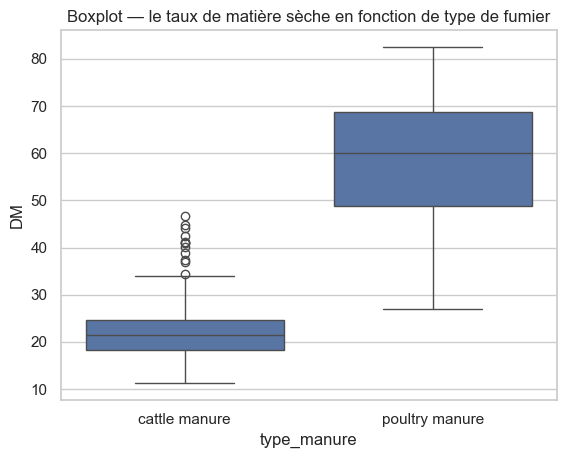

In [25]:
plt.figure()
if sns:
    sns.boxplot(x="type_manure", y="DM", data=df)
else:
    groups = [g["DM"].values for _, g in df.groupby("type_manure")]
    labels = df["type_manure"].unique()
    plt.boxplot(groups, labels=labels)
plt.title("Boxplot — le taux de matière sèche en fonction de type de fumier")
plt.show()

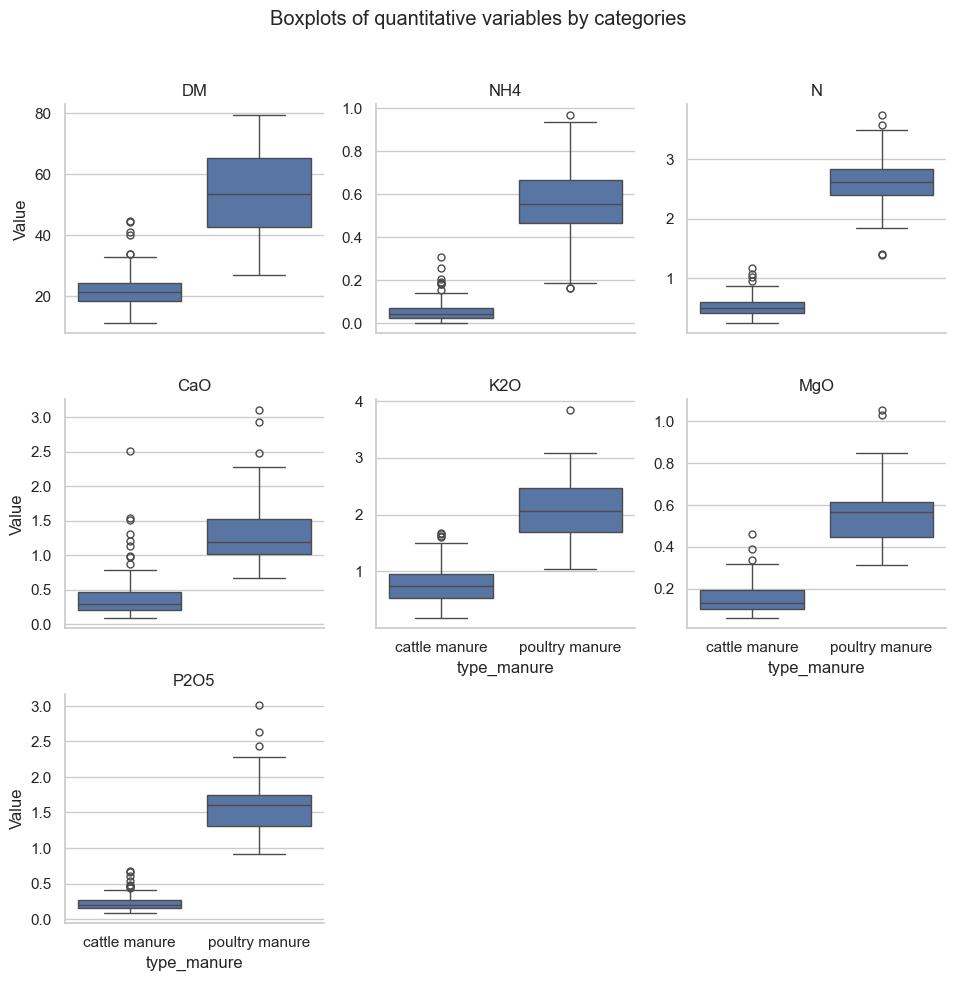

In [26]:
quant_vars = Quant  
qual_x = "type_manure"       

df_plot = df[quant_vars + [qual_x]].dropna().copy()

# Mise au format long pour FacetGrid
df_melt = df_plot.melt(
    id_vars=[qual_x ],
    value_vars=quant_vars,
    var_name="Variable",
    value_name="Value"
)

# Grille de boxplots
g = sns.catplot(
    data=df_melt,
    x=qual_x, y="Value",
    col="Variable",
    col_wrap=3,        
    kind="box",
    height=3.2,
    sharey=False
)

g.set_titles("{col_name}")
g.set_axis_labels(qual_x)
g.fig.suptitle("Boxplots of quantitative variables by categories", y=1.02)
plt.tight_layout()
plt.show()


### Analyse de la corrélation entre variables quantitatives et le type de fumier

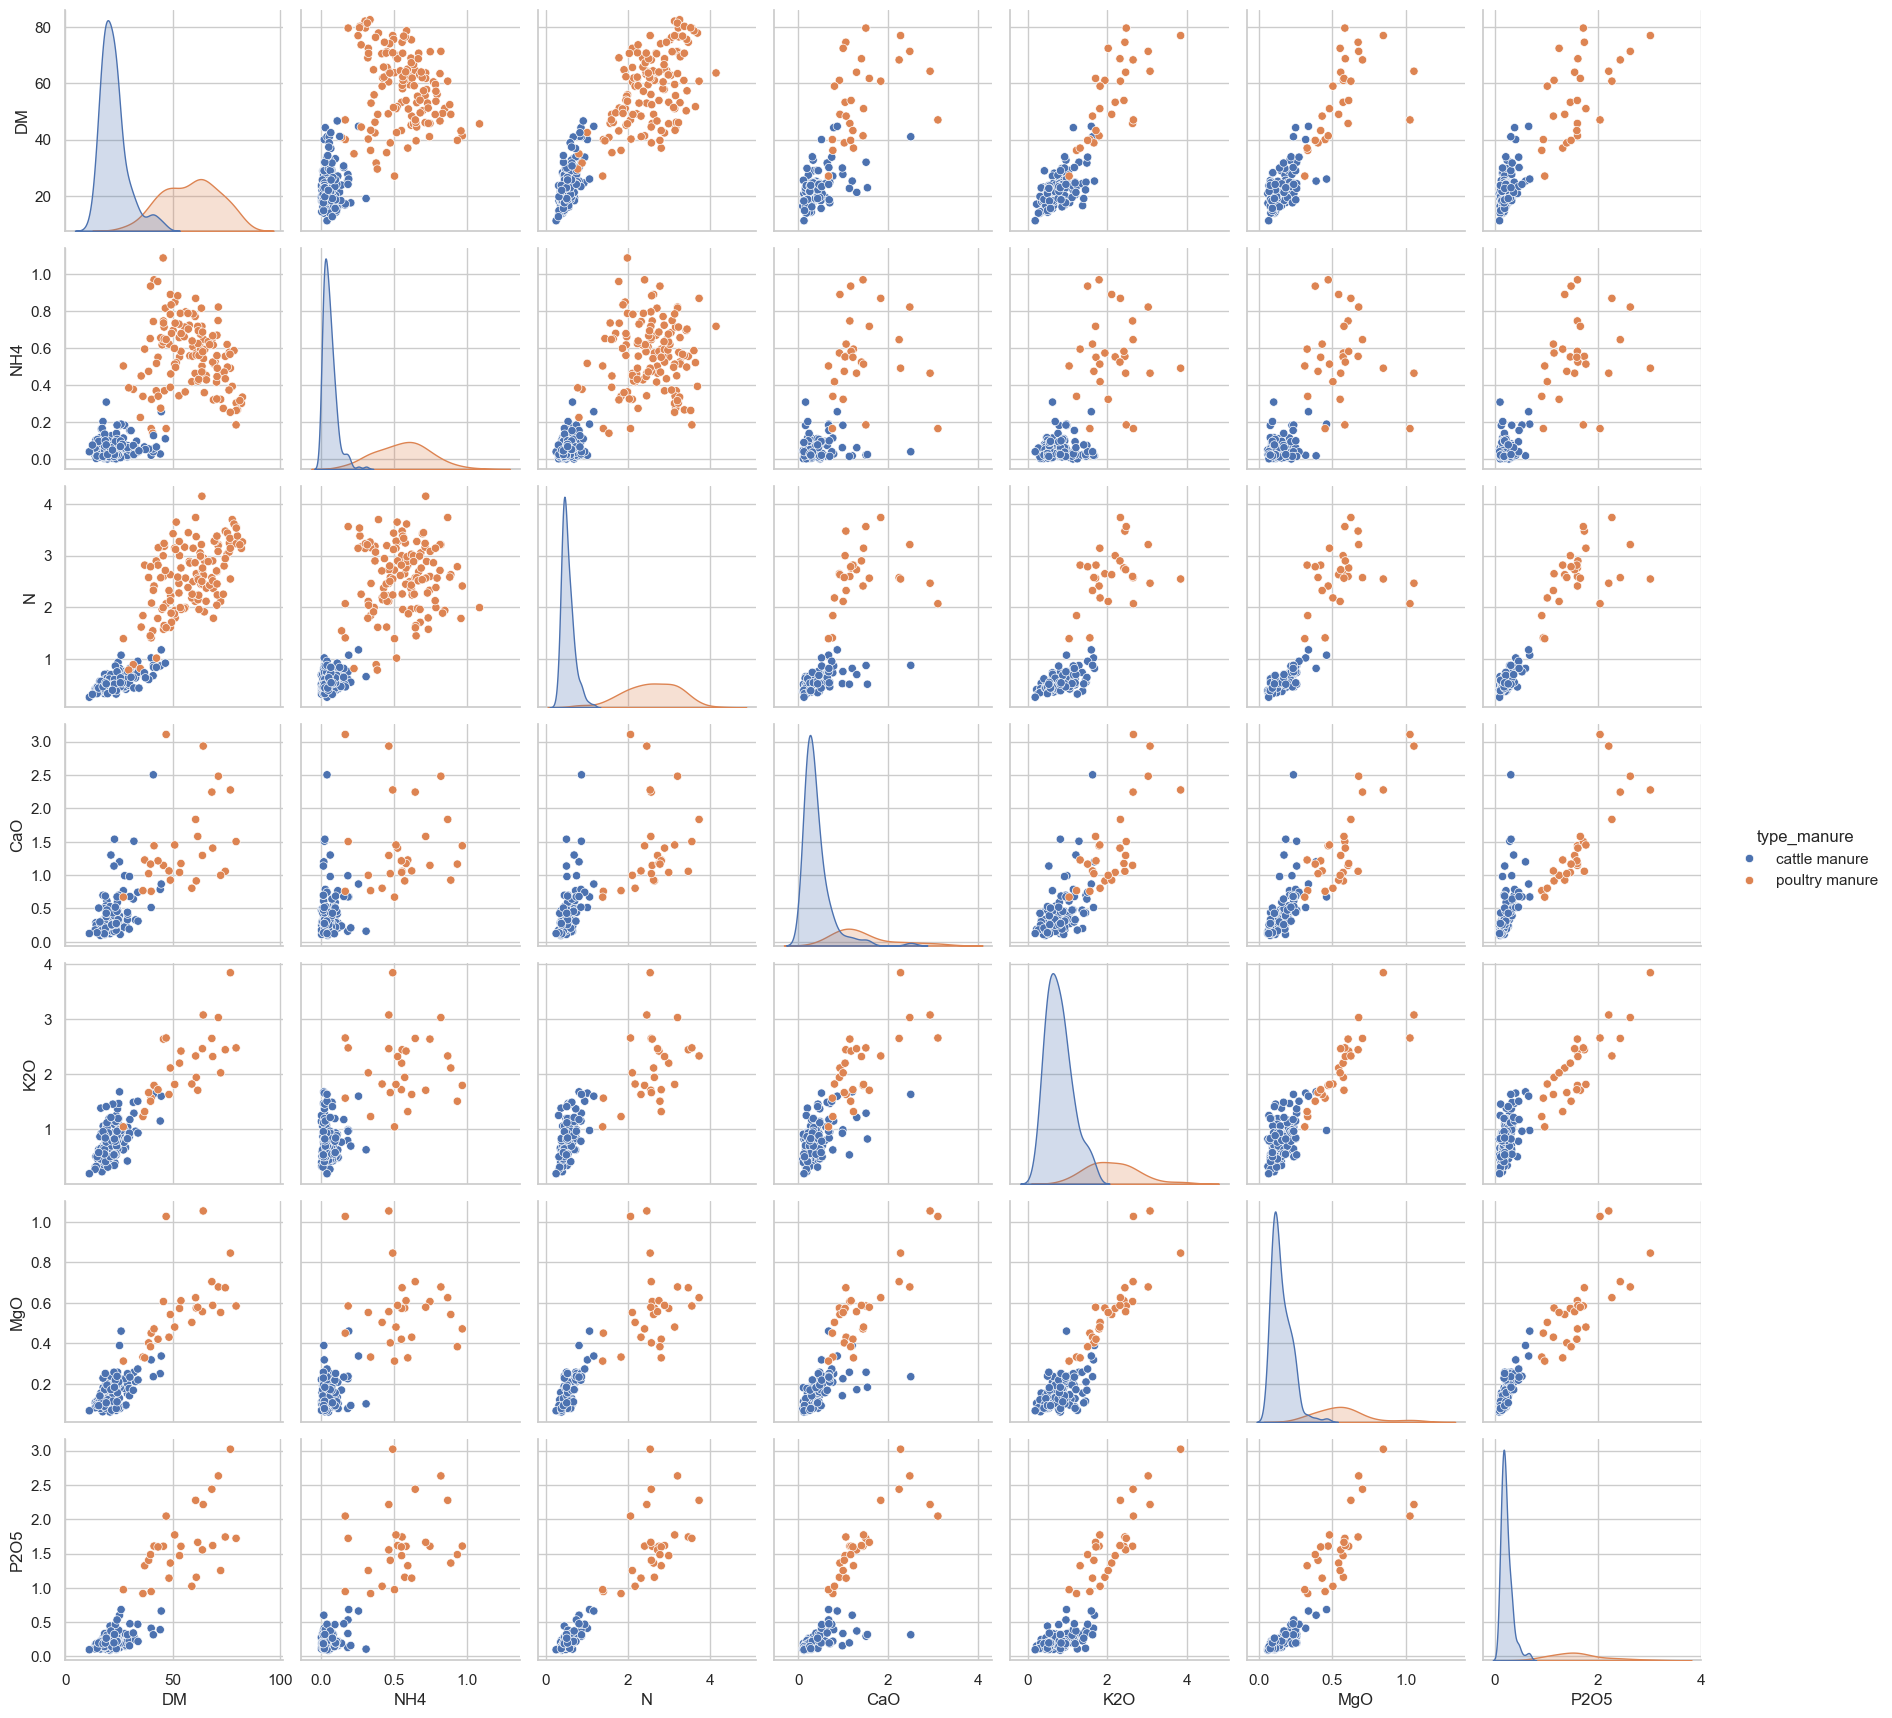

In [27]:
# pairplot

p = sns.pairplot(df[Quant + ['type_manure']], hue='type_manure')

## Analyse en composante principale

- Nous allons projeter en deux dimentions les 699 variables spectrales NIR

In [28]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [29]:
#normalisation des données spectrales avant ACP
scaler_1= StandardScaler()
scaler_2= StandardScaler()

X_scaled_FH = scaler_1.fit_transform(df_FH)
X_scaled_DG = scaler_2.fit_transform(df_DG)

In [30]:
X_scaled_DG[:5]

array([[-1.00560114, -1.00782803, -1.00870666, ..., -1.30177145,
        -1.3019938 , -1.30211642],
       [-0.90447051, -0.9045054 , -0.90487858, ..., -1.21999067,
        -1.22185027, -1.22381297],
       [-0.71683664, -0.71569674, -0.71504244, ..., -1.06635317,
        -1.06804153, -1.06948642],
       [-0.71906218, -0.71877538, -0.71862018, ..., -1.14193284,
        -1.14328579, -1.1448093 ],
       [-0.94869244, -0.94798572, -0.94639329, ..., -1.23103436,
        -1.23346841, -1.23589028]])


### Ajuster une ACP avec 4 composantes

On commence par calculer autant de composantes principales que de variables (4).

In [31]:
ACP_FH = PCA(n_components=4)
ACP_DG = PCA(n_components=4)

visual_humide = ACP_FH.fit_transform(df_FH)
visual_sec = ACP_DG.fit_transform(df_DG)

# Variance expliquée par chaque composante
explained_variance_FH = ACP_FH.explained_variance_ratio_
explained_variance_DG = ACP_DG.explained_variance_ratio_
print("FH" ,explained_variance_FH ,"\n DG",explained_variance_DG)

FH [0.96211905 0.03200764 0.00372096 0.0015325 ] 
 DG [0.9011656  0.08915103 0.0046846  0.00351588]


#### Choix du nombre d'axes

In [32]:
# Analyse des valeurs propres
n = min(4, len(ACP_FH.explained_variance_))

comp = pd.DataFrame({
    "Dimension": [f"Dim{i+1}" for i in range(n)],
    "Valeur propre": ACP_FH.explained_variance_[:n],
    "% variance expliquée": np.round(ACP_FH.explained_variance_ratio_[:n] * 100, 2),
    "% cum. var. expliquée": np.round(np.cumsum(ACP_FH.explained_variance_ratio_[:n]) * 100, 2),
})

comp

,Dimension,Valeur propre,% variance expliquée,% cum. var. expliquée
0,Dim1,63.720473,96.21,96.21
1,Dim2,2.119844,3.20,99.41
2,Dim3,0.246436,0.37,99.78
3,Dim4,0.101496,0.15,99.94


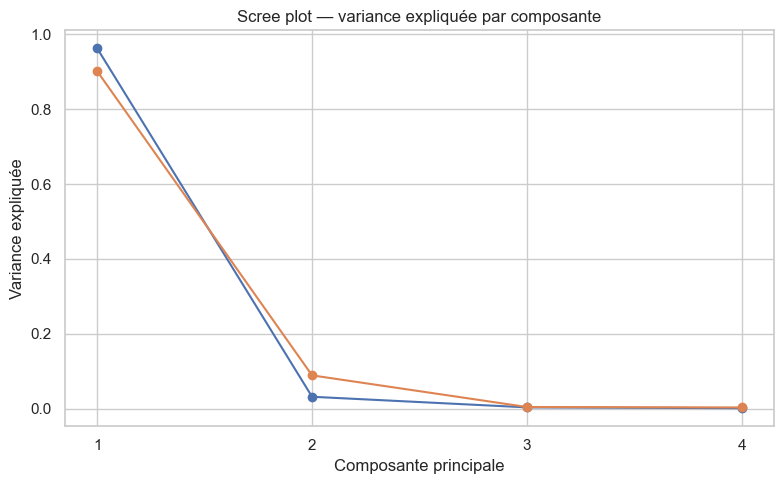

Variance expliquée cumulée pour FH : [0.96211905 0.99412669 0.99784764 0.99938014] 
 Variance expliquée cumulée pour DG : [0.9011656  0.99031663 0.99500123 0.99851711]


In [33]:
#Scree plot
plt.figure(figsize=(8,5))
components = np.arange(1, 5)
plt.plot(components, explained_variance_FH, marker='o')
plt.plot(components, explained_variance_DG, marker='o')
plt.xticks(components)
plt.xlabel("Composante principale")
plt.ylabel("Variance expliquée")
plt.title("Scree plot — variance expliquée par composante")
plt.grid(True)
plt.tight_layout()
plt.show()

print("Variance expliquée cumulée pour FH :" , np.cumsum(explained_variance_FH) ,"\n Variance expliquée cumulée pour DG :",  np.cumsum(explained_variance_DG))

- Avec la méthode du coude on peut sélectionner le nombre de composante principale: **2** est le nombre de composantes principale à partir duquel la variance expliquée devient marginale.

###  ACP en 2 dimensions : projection dans le plan (PC1, PC2)

In [34]:
ACP_2_FH = PCA(n_components=2)
ACP_2_DG = PCA(n_components=2)

visual_humide = ACP_2_FH.fit_transform(X_scaled_FH)
visual_sec = ACP_2_DG.fit_transform(X_scaled_DG)

df_pca_FH = pd.DataFrame(visual_humide, columns=["PC1_FH", "PC2_FH"])
df_pca_DG = pd.DataFrame(visual_sec, columns=["PC1_DG", "PC2_DG"])
df_pca_FH["type_manure"] = df["type_manure"].iloc[:len(df_pca_FH)].values
df_pca_DG["type_manure"] = df["type_manure"].iloc[:len(df_pca_DG)].values


# Variance expliquée par chaque composante
explained_variance_FH = ACP_2_FH.explained_variance_ratio_
explained_variance_DG = ACP_2_DG.explained_variance_ratio_
print("FH" ,explained_variance_FH ,"\n DG",explained_variance_DG)

FH [0.93211596 0.06172133] 
 DG [0.89501973 0.09558561]


In [35]:
from sklearn.cluster import KMeans
kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=20
)

clusters = kmeans.fit_predict(
    df_pca_FH[["PC1_FH", "PC2_FH",]]
)

df_pca_FH["cluster"] = clusters

c:\Users\gille\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


## Representation graphique de l'ACP et interprétation

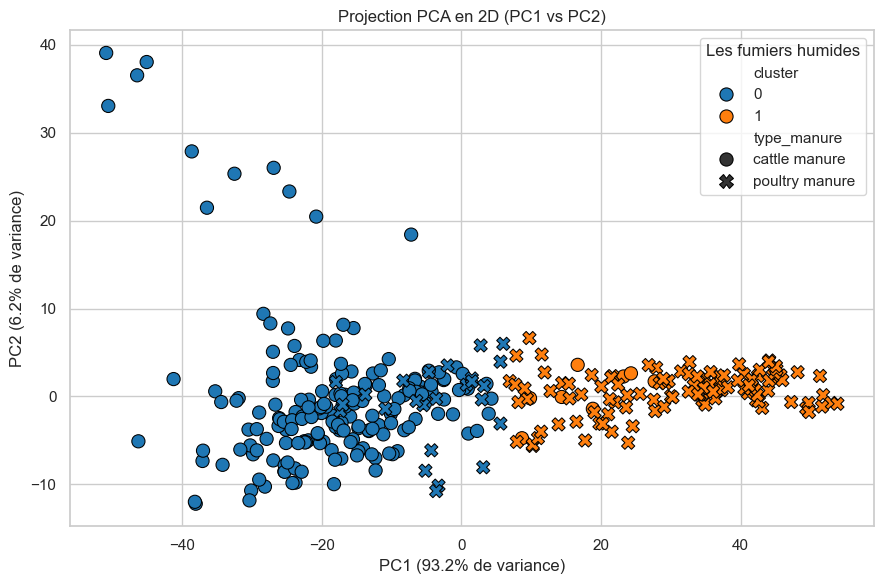

In [36]:

plt.figure(figsize=(9,6))

sns.scatterplot(
    data=df_pca_FH,
    x="PC1_FH",
    y="PC2_FH",
    hue="cluster",
    style="type_manure",
    palette="tab10",
    s=90,
    edgecolor="black"
)


plt.title("Projection PCA en 2D (PC1 vs PC2)")
plt.xlabel(f"PC1 ({ACP_2_FH.explained_variance_ratio_[0]*100:.1f}% de variance)")
plt.ylabel(f"PC2 ({ACP_2_FH.explained_variance_ratio_[1]*100:.1f}% de variance)")
plt.legend(title="Les fumiers humides")
plt.tight_layout()
plt.show()


In [37]:
X_ = np.hstack([X_scaled_FH, X_scaled_DG])
ACP_2_DG = PCA(n_components=2)
visual = ACP_2_DG.fit_transform(X_)
df_pca_DG = pd.DataFrame(visual, columns=["PC1_DG", "PC2_DG"])
df_pca_DG["type_manure"] = df["type_manure"].iloc[:len(df_pca_DG)].values

kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=20
)

clusters = kmeans.fit_predict(
    df_pca_DG[["PC1_DG", "PC2_DG"]]
)

df_pca_DG["cluster"] = clusters

c:\Users\gille\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


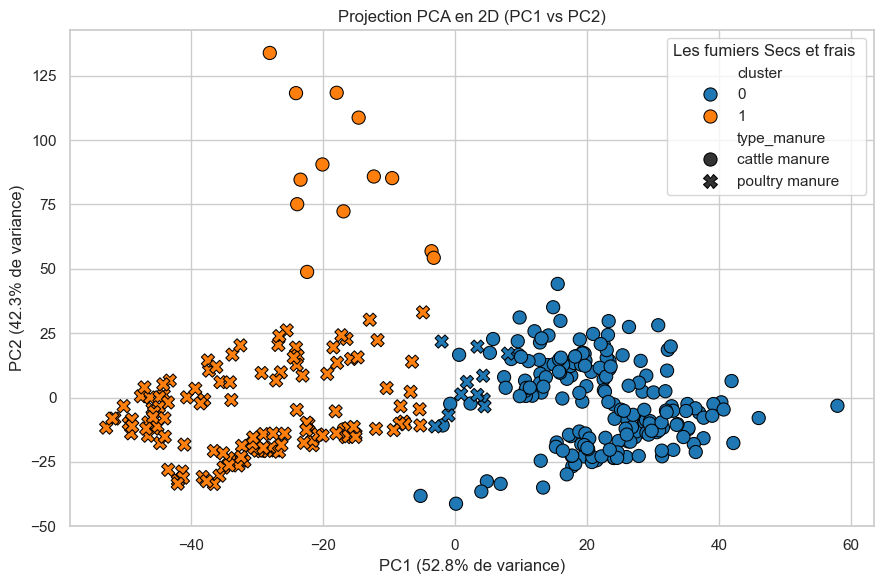

In [38]:
plt.figure(figsize=(9,6))
sns.scatterplot(
    data=df_pca_DG,
    x="PC1_DG",
    y="PC2_DG",
    hue="cluster",
    style="type_manure",
    palette="tab10",
    s=90,
    edgecolor="black"
)

plt.title("Projection PCA en 2D (PC1 vs PC2)")
plt.xlabel(f"PC1 ({ACP_2_DG.explained_variance_ratio_[0]*100:.1f}% de variance)")
plt.ylabel(f"PC2 ({ACP_2_DG.explained_variance_ratio_[1]*100:.1f}% de variance)")
plt.legend(title="Les fumiers Secs et frais ")
plt.tight_layout()
plt.show()


**Interprétation**: 
- Deux composantes principales ont été retenue pour Cette ACP, CP1 avec 52.8% de variance explicative et CP2 avec 42.3% de variance explicative ce qui totalise 95.1% de variance explicative

- Suite à l'ACP effectué sur les données spectrales NIR pour les fumiers secs et humides, une observation est indéniable, c'est qu'il y'a formation de clusters naturels qui sont influencé par le type de fumier à savoir celui de bovin d'un côté et le fumier de volaille de l'autre. Nous avons aussi mis en exergue sur ce visuel d'ACP une classification par KMeans pour observer les clusters crée à partir de centroïdes. Pour les deux centroïdes choisis les différences sont minimes voir négligeables comparées à ceux des clusters naturels observés. Ces clusters formés nous conduisent à envisager deux modèles de regressions locaux pour optimiser la robustesse des modèles : 1 modèle pour le fumier de bovin et un autre pour le fumier de volaille. 

In [66]:
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, confusion_matrix
df_final = pd.concat([df_fh, df_DG], axis=1)


iso_forest = IsolationForest(contamination=0.1, random_state=42)
outlier_labels = iso_forest.fit_predict(df_pca_DG["PC1_DG"].values.reshape(-1, 1), df_pca_DG["PC2_DG"].values.reshape(-1, 1))

df_pca_DG['Outlier']= outlier_labels

outliers = df_pca_DG[df_pca_DG['Outlier'] == -1]  
print(f"Outliers détectés: {(outliers)}")

Outliers détectés:         PC1_DG     PC2_DG     type_manure  cluster  Outlier
28   40.362644  -1.875383   cattle manure        0       -1
30   39.156834  -2.533213   cattle manure        0       -1
31   41.908493   6.398160   cattle manure        0       -1
47   40.702693  -4.651526   cattle manure        0       -1
88   38.974716  -7.086923   cattle manure        0       -1
154  46.021737  -7.976824   cattle manure        0       -1
155  57.948218  -3.218020   cattle manure        0       -1
166  42.179141 -17.690366   cattle manure        0       -1
189 -38.223080 -30.875234  poultry manure        1       -1
203  -6.730457   2.214802  poultry manure        1       -1
205 -40.999034 -18.295745  poultry manure        1       -1
212 -41.338425 -28.778436  poultry manure        1       -1
236 -41.971486 -32.287347  poultry manure        1       -1
238 -41.213481 -31.154113  poultry manure        1       -1
242  -9.278572 -12.671801  poultry manure        1       -1
243 -42.002286 -33.48

In [40]:
loadings = pd.DataFrame(
    ACP_2_DG.components_.T,
    columns=["PC1_DG", "PC2_DG"],
)
loadings.head


<bound method NDFrame.head of         PC1_DG    PC2_DG
0     0.017479  0.029890
1     0.017498  0.029897
2     0.017502  0.029919
3     0.017510  0.029940
4     0.017528  0.029959
...        ...       ...
1395 -0.029267  0.020934
1396 -0.029269  0.020920
1397 -0.029269  0.020913
1398 -0.029267  0.020914
1399 -0.029265  0.020921

[1400 rows x 2 columns]>

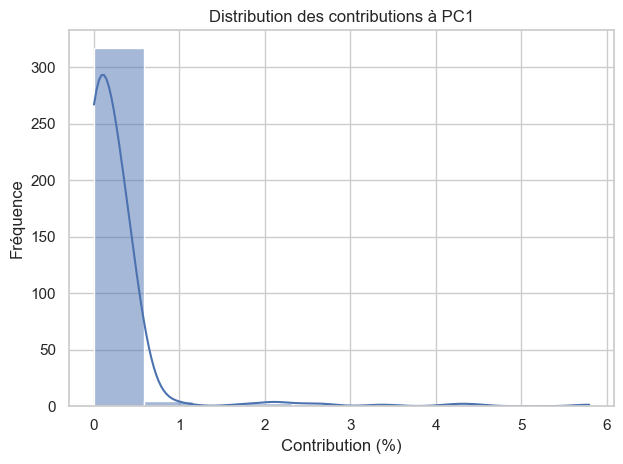

In [41]:
# Calculer la contribution des individus à la formation des axes
eigenvalues = ACP_2_DG.explained_variance_
contributions = (visual_sec**2) / (visual_sec.shape[0] * eigenvalues)

# Convertir les contributions en pourcentage
contrib_percent = contributions * 100

# Créer un DataFrame pour faciliter l'affichage des résultats
column_names = [f'PC{i+1}_contrib' for i in range(2)]
contrib_df = pd.DataFrame(contrib_percent, columns=column_names)

sns.histplot(contrib_df["PC1_contrib"], bins=10, kde=True)
plt.title("Distribution des contributions à PC1")
plt.xlabel("Contribution (%)")
plt.ylabel("Fréquence")
plt.grid(True)
plt.tight_layout()
plt.show()

In [1]:
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D

# ==============================================================================
# PARAMÈTRES
# ==============================================================================

PC1_DG = 0
PC2_DG = 1
expl_colors = ["#E53935", "#8E24AA", "#00897B", "#F4511E", "#1565C0", "#F57C00", "#6D4C41"]

# ==============================================================================
# LOADINGS — extraire uniquement la portion DG
# ==============================================================================

n_cols_FH = X_scaled_FH.shape[1]
n_cols_DG = X_scaled_DG.shape[1]

eigenvalues  = ACP_2_DG.explained_variance_
loadings_all = ACP_2_DG.components_.T * np.sqrt(eigenvalues)

loadings = loadings_all[n_cols_FH : n_cols_FH + n_cols_DG]   # bloc DG uniquement

var_exp = ACP_2_DG.explained_variance_ratio_ * 100

# ==============================================================================
# CORRÉLATIONS VARIABLES EXPLICATIVES ↔ COMPOSANTES
# ==============================================================================

scores = visual
X_expl = df[["DM", "CaO", "N", "NH4", "K2O", "P2O5", "MgO"]]

expl_corr = np.zeros((X_expl.shape[1], 2))

for j, col in enumerate(X_expl.columns):
    for k in range(2):
        expl_corr[j, k] = np.corrcoef(X_expl[col].values, scores[:, k])[0, 1]

# ==============================================================================
# CERCLE DE CORRÉLATION
# ==============================================================================

fig, ax = plt.subplots(figsize=(11, 10))

theta = np.linspace(0, 2 * np.pi, 300)
ax.plot(np.cos(theta), np.sin(theta), color="gray", lw=1, ls="--", alpha=0.5)
ax.axhline(0, color="gray", lw=0.7, alpha=0.4)
ax.axvline(0, color="gray", lw=0.7, alpha=0.4)

# --- Vecteurs spectraux colorés par longueur d'onde
wl_numeric = np.array([float(c) for c in X.columns])
norm       = mcolors.Normalize(vmin=wl_numeric.min(), vmax=wl_numeric.max())
cmap       = cm.colormaps["rainbow"]

n_wl       = len(wl_numeric)
label_step = max(1, n_wl // 20)

for i in range(n_wl):
    cx    = loadings[i, PC1_DG]
    cy    = loadings[i, PC2_DG]
    color = cmap(norm(wl_numeric[i]))

    ax.annotate("", xy=(cx, cy), xytext=(0, 0),
                arrowprops=dict(arrowstyle="-|>", color=color, lw=0.8, alpha=0.55))

    if i % label_step == 0:
        ax.text(cx * 1.06, cy * 1.06, str(int(wl_numeric[i])),
                fontsize=6.5, color=color, ha="center", va="center")

# Colorbar longueurs d'onde
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, fraction=0.03, pad=0.04)
cbar.set_label("Longueur d'onde (nm)", fontsize=10)

# --- Vecteurs des variables explicatives
for j, col in enumerate(X_expl.columns):
    ex = expl_corr[j, PC1_DG]
    ey = expl_corr[j, PC2_DG]
    ec = expl_colors[j]

    ax.annotate("", xy=(ex, ey), xytext=(0, 0),
                arrowprops=dict(arrowstyle="-|>", color=ec, lw=2.5, mutation_scale=15))

    ax.text(ex * 1.1, ey * 1.1, col, fontsize=10, fontweight="bold", color=ec,
            ha="center", va="center",
            bbox=dict(boxstyle="round,pad=0.2", fc="white", ec=ec, alpha=0.85, lw=1))

# --- Légende
legend_elems = [Line2D([0], [0], color="#90CAF9", lw=1.5, label="Variables spectrales")]
for j, col in enumerate(X_expl.columns):
    legend_elems.append(Line2D([0], [0], color=expl_colors[j], lw=2.5, label=col))
ax.legend(handles=legend_elems, loc="lower left", fontsize=9, framealpha=0.9)

# --- Mise en forme
ax.set_xlim(-1.25, 1.25)
ax.set_ylim(-1.25, 1.25)
ax.set_aspect("equal")
ax.set_xlabel(f"PC1_DG ({var_exp[PC1_DG]:.1f}%)", fontsize=12)
ax.set_ylabel(f"PC2_DG ({var_exp[PC2_DG]:.1f}%)", fontsize=12)
ax.set_title("Cercle de corrélation — PC1_DG vs PC2_DG", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.show()

NameError: name 'X_scaled_FH' is not defined

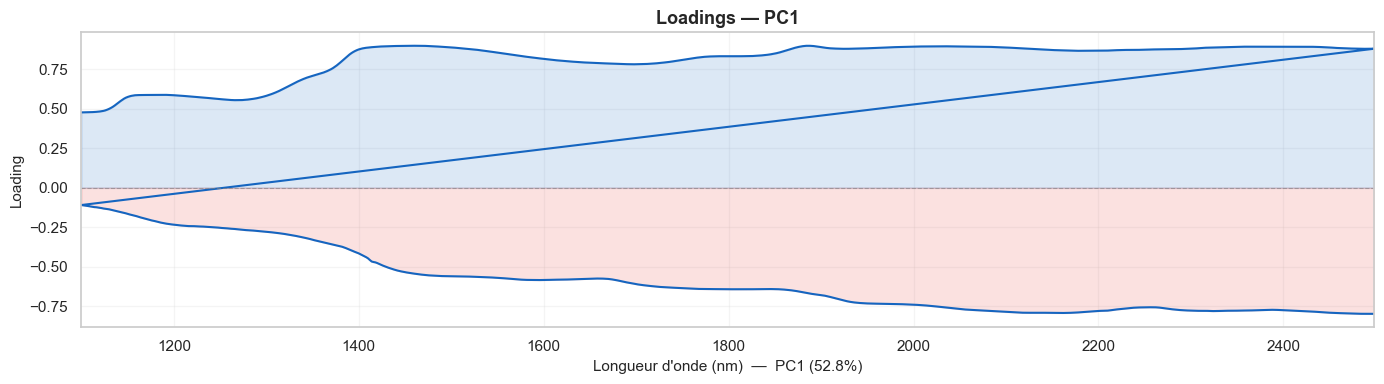

In [43]:

# ==============================================================================
# LOADINGS PC1 en fonction des longueurs d'onde
# ==============================================================================

# Choisir quelle composante afficher
pc_index = 0   # 0 = PC1, 1 = PC2, ...

# Extraire les loadings uniquement
eigenvalues = ACP_2_DG.explained_variance_
#loadings_all = (visual_sec**2) / (visual_sec.shape[0] * eigenvalues)
loadings_all = ACP_2_DG.components_.T * np.sqrt(eigenvalues)

# Longueurs d'onde (depuis le DataFrame original, pas le numpy array)
X_spectral = pd.concat([df_FH, df_DG], axis=1)
wl_numeric = np.array([float(c.replace("_nm", "")) for c in X_spectral.columns])

loadings     = loadings_all   # tous les loadings, pas juste le bloc DG

# Valeurs des loadings pour la composante choisie
loading_curve = loadings[:, pc_index]

# ==============================================================================
# TRACÉ
# ==============================================================================

fig, ax = plt.subplots(figsize=(14, 4))

ax.plot(wl_numeric, loading_curve, color="#1565C0", lw=1.5)
ax.axhline(0, color="gray", lw=0.8, ls="--", alpha=0.6)

# Remplissage sous/sur la courbe pour mieux lire les zones positives/négatives
ax.fill_between(wl_numeric, loading_curve, 0,
                where=(loading_curve >= 0), color="#1565C0", alpha=0.15)
ax.fill_between(wl_numeric, loading_curve, 0,
                where=(loading_curve < 0),  color="#E53935", alpha=0.15)

ax.set_xlabel(f"Longueur d'onde (nm)  —  PC{pc_index+1} ({var_exp[pc_index]:.1f}%)", fontsize=11)
ax.set_ylabel("Loading", fontsize=11)
ax.set_title(f"Loadings — PC{pc_index+1}", fontsize=13, fontweight="bold")
ax.set_xlim(wl_numeric.min(), wl_numeric.max())
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

### Elimination des outliers

# Modelèle de classification : KNN
### Prétraitement des données

In [44]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier

X = df_FH
#Encodage
df['type_manure'].replace(["cattle manure","poultry manure"], [0,1], inplace= True) 
y = df['type_manure']
# Diviser la base de données en train et test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

C:\Users\gille\AppData\Local\Temp\ipykernel_10548\1232708994.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['type_manure'].replace(["cattle manure","poultry manure"], [0,1], inplace= True)
C:\Users\gille\AppData\Local\Temp\ipykernel_10548\1232708994.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting',

In [45]:
model = KNeighborsClassifier()

In [46]:
from sklearn.metrics import f1_score, confusion_matrix , classification_report
from sklearn.model_selection import learning_curve

In [47]:
def evaluation (model):
    model.fit(X_train,y_train)
    ypred = model.predict(X_test)
    
    print(confusion_matrix(y_test, ypred))
    print(classification_report(y_test, ypred))

    N, train_score, val_score= learning_curve(model, X_train, y_train, cv=5, scoring= "f1")
    
    plt.figure(figsize= (12,8))
    plt.plot(N, train_score.mean(axis=1), label= "train score")
    plt.plot(N, val_score.mean(axis=1), label= "validation score")
    plt.legend()
    plt.show()

[[41  1]
 [ 2 23]]
              precision    recall  f1-score   support

           0       0.95      0.98      0.96        42
           1       0.96      0.92      0.94        25

    accuracy                           0.96        67
   macro avg       0.96      0.95      0.95        67
weighted avg       0.96      0.96      0.96        67



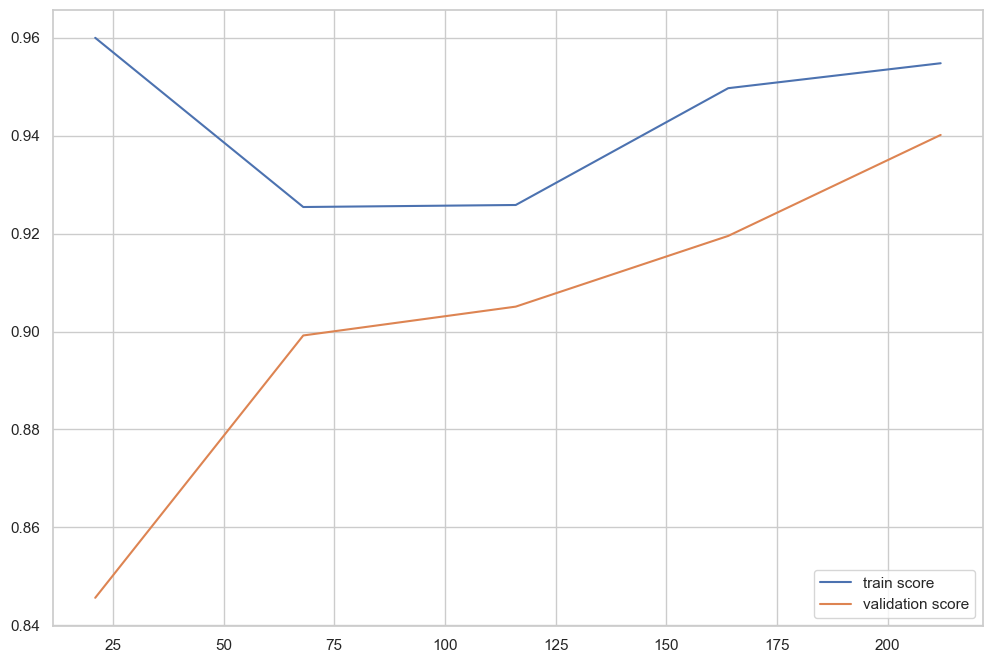

In [48]:
evaluation(model)

In [49]:
pd.DataFrame(model.feature_importances_, index= X_train.columns).plot.bar(figsize=(12,8))

AttributeError: 'KNeighborsClassifier' object has no attribute 'feature_importances_'

In [ ]:
pls = best_model.named_steps["pls"]
step = 50

loadings = pls.x_loadings_ 
importance = np.linalg.norm(loadings[:, :best_ncomp], axis=1)
plt.figure(figsize=(16,7))
plt.plot(wavelengths, importance)
plt.title("Importance des longueurs d’onde (loadings PLS)")
plt.xlabel("Longueur d’onde (cm-1)")
plt.ylabel("intensité")
plt.xticks(wavelengths[::step], rotation=90)
plt.grid(True)
plt.show()

In [ ]:
def vache(model,  type_manure=0):
    x= np.array([ type_manure]).reshape(1,1)
    print(model.predict(x))

In [ ]:
# Liste des valeurs de k à tester
k_values = list(range(1, 30))

In [ ]:
# Création de l'instance du classificateur KNN
knn = KNeighborsClassifier()
# Paramètres pour la recherche de grille
param_grid = {'n_neighbors': k_values}

# Recherche de grille avec validation croisée
grid_search = GridSearchCV(knn, param_grid, cv=5)
grid_search.fit(X_train, y_train)

# Extraction des scores de validation croisée et des valeurs de k correspondantes
cv_scores = grid_search.cv_results_['mean_test_score']
best_k = grid_search.best_params_['n_neighbors']

In [ ]:
best_k

In [ ]:
# Tracé du graphique des scores de validation croisée en fonction de k
plt.plot(k_values, cv_scores, '-o')
plt.xlabel('Valeur de k')
plt.ylabel('Score de validation croisée')
plt.title('Choix de k par validation croisée')
plt.xticks(k_values)
plt.axvline(x=best_k, color='r', linestyle='--', label='Meilleur k')
plt.legend()
plt.show()

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score, accuracy_score
best_model=grid_search.best_estimator_
# Prédiction sur l'ensemble d'entraînement
y_train_pred = best_model.predict(X_train)
y_train_pred_proba = best_model.predict_proba(X_train)[:, 1]

# Prédiction sur l'ensemble de test
y_test_pred = best_model.predict(X_test)
y_test_pred_proba = best_model.predict_proba(X_test)[:, 1]

# Calcul de l'exactitude sur les ensembles d'entraînement et de test
accuracy_train = accuracy_score(y_train, y_train_pred)
accuracy_test = accuracy_score(y_test, y_test_pred)
print("Exactitude sur l'ensemble d'entraînement : {:.2f}%".format(accuracy_train * 100))
print("Exactitude sur l'ensemble de test : {:.2f}%".format(accuracy_test * 100))

# Modele de regression PLS

**info**: Comme enoncé dans les objectifs, le modèle de prédiction a pour but de prédire les propriétés chimiques du fumier. Pour se faire les variables features seront les variables spectrales et les variables réponses les propriétés chimiques.

In [50]:
from sklearn.model_selection import RandomizedSearchCV, train_test_split 
from sklearn.metrics import r2_score, mean_squared_error, explained_variance_score, mean_absolute_error
from sklearn.cross_decomposition import PLSRegression

In [58]:
df_final = pd.concat([df_fh, df_DG], axis=1)
_B= df_final[df_final["type_manure"] == "cattle manure"]
X_B= _B.drop(columns=["type_manure", "spectrometer", "country","N", "DM","NH4","township","CaO", "K2O", "MgO","P2O5"], errors="ignore") #variables spectrales pour le fumier de bovin
_V=df_final[df_final["type_manure"] == "poultry manure"]
X_V= _V.drop(columns=["type_manure", "spectrometer", "country","N", "DM","NH4","township","CaO", "K2O", "MgO","P2O5"], errors="ignore") #variables spectrales pour le fumier de volaille


X1 = df_FH
X2 = df_DG
X = np.hstack([X1, X2])

Y  = df_quant
Y_N= _V[["N"]]

In [59]:
X_train, X_test, \
Y_N_train, Y_N_test = train_test_split(
    X_V , Y_N,
    test_size=0.2,
    random_state=42
)

### 1er modèle de régression
- Sans optimisation

In [60]:
from sklearn.model_selection import cross_val_score


pls_model = PLSRegression(n_components=2)
pls_model.fit(X_train, Y_N_train)

PLSRegression()
y_pred_cal = pls_model.predict(X_train)
y_pred_val = pls_model.predict(X_test)




In [61]:
r2_CAL = r2_score(Y_N_train , y_pred_cal)
r2_VAL = r2_score(Y_N_test , y_pred_val)

rmsec = np.sqrt(mean_squared_error(Y_N_train , y_pred_cal))
rmsep = np.sqrt(mean_squared_error(Y_N_test, y_pred_val))

MAE_CAL = mean_absolute_error(Y_N_train , y_pred_cal)
MAE_VAL = mean_absolute_error(Y_N_test , y_pred_val)
#Cette dernière métrique est moins sensible aux valeurs aberrantes que le RMSE, car elle ne prend pas en compte le carré des erreurs. Elle donne une mesure plus directe de l'erreur moyenne en unités de la variable cible, ce qui peut être plus interprétable dans certains contextes. En revanche, le RMSE pénalise davantage les grandes erreurs, ce qui peut être utile si vous souhaitez accorder plus d'importance à la précision des prédictions.

#AFFICHAGE DES RESULTATS ET DU GRAPHE Pred vs Ref
performance_table = pd.DataFrame({
    "Metrique": ['R²' ,'RMSE' , 'MAE'],
    'calibration': [r2_CAL ,rmsec ,MAE_CAL],
    'Validation' : [r2_VAL ,rmsep, MAE_VAL]
    
})
print(performance_table)  

  Metrique  calibration  Validation
0       R²     0.457585    0.305818
1     RMSE     0.488034    0.478540
2      MAE     0.394997    0.386917


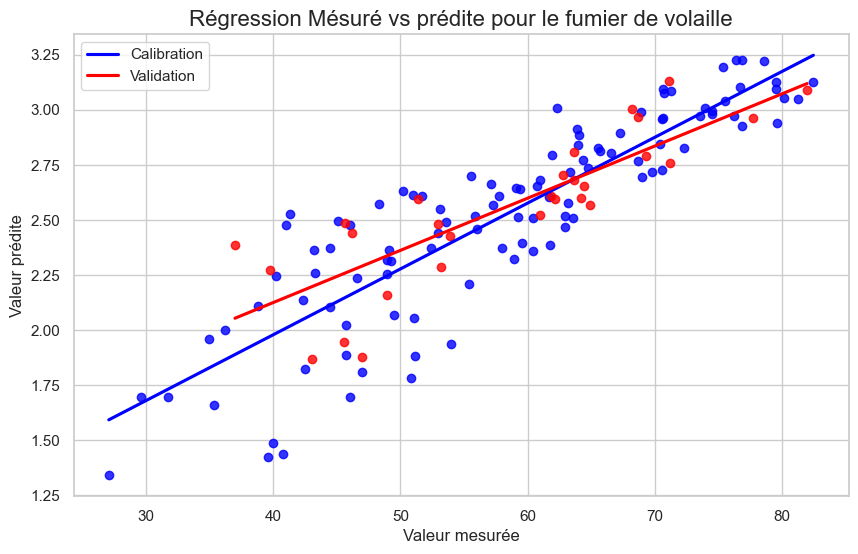

In [62]:
plt.figure(figsize=(10, 6))

# Nuage de points

sns.regplot(x=Y_DM_train, y=y_pred_cal, robust=False ,fit_reg=True, color="blue",ci=None,  line_kws={'label':"Calibration"})
sns.regplot(x=Y_DM_test, y=y_pred_val, robust=True ,fit_reg=True, color="red",ci=None,  line_kws={'label':"Validation"})

plt.title("Régression Mésuré vs prédite pour le fumier de volaille", fontsize=16)
plt.xlabel("Valeur mesurée", fontsize=12)
plt.ylabel("Valeur prédite", fontsize=12)
plt.legend()
plt.grid(True)

plt.show()

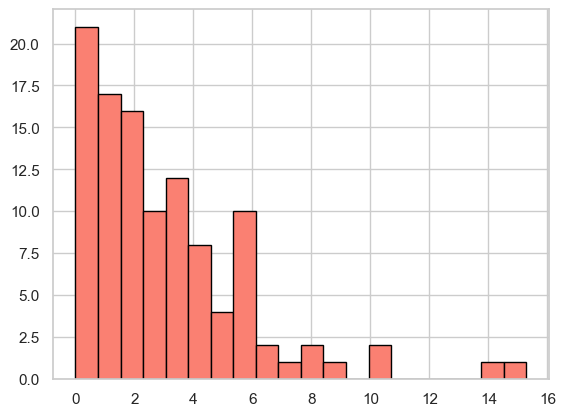

In [56]:
err_hist = np.abs(Y_DM_train - y_pred_cal)
plt.hist(err_hist, bins=20, color="salmon", edgecolor="black")
plt.show()

### 2eme modèle: modèle avec optimisation

In [57]:
df_new = df_new.copy()

X = np.hstack([X1, X2])
Y_dict_B = {
    "NH4": _B["NH4"],
    "N":_B["N"],
    "CaO": _B["CaO"],
    "K2O": _B["K2O"],
    "MgO": _B["MgO"],
    "P2O5": _B["P2O5"],
    "DM": _B["DM"]
    }
Y_dict_V= {
    "NH4": _V["NH4"],
    "N":_V["N"],
    "CaO": _V["CaO"],
    "K2O": _V["K2O"],
    "MgO": _V["MgO"],
    "P2O5": _V["P2O5"],
    "DM": _V["DM"]
    }


NameError: name 'df_new' is not defined

In [ ]:
splits = {}

for name, y in Y_dict_V.items():

    # Supprimer les lignes où la variable réponse est manquante
    mask = ~y.isna()

    X_temp = X_V[mask]
    y_temp = y[mask].values

    X_train, X_test, y_train, y_test = train_test_split(
        X_temp,
        y_temp,
        test_size=0.2,
        random_state=42
    )

    splits[name] = (X_train, X_test, y_train, y_test)

    print(f"{name} → Train shape: {X_train.shape}")


NH4 → Train shape: (108, 1400)
N → Train shape: (108, 1400)
CaO → Train shape: (22, 1400)
K2O → Train shape: (22, 1400)
MgO → Train shape: (22, 1400)
P2O5 → Train shape: (22, 1400)
DM → Train shape: (108, 1400)


In [ ]:
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.pipeline import Pipeline

In [ ]:
from sklearn.model_selection import cross_validate, KFold
models = {}
predictions = {}

for name, (X_train, X_test, y_train, y_test) in splits.items():

    # Création du modèle
    pls_model_2 = Pipeline([
    ("feature_selection", SelectKBest(k=700)),
    ("scaler", StandardScaler()),
    ("pls", PLSRegression(n_components=2))])

    # Fit
    pls_model_2.fit(X_train, y_train)

    # Predict
    y_pred_train = pls_model_2.predict(X_train)
    y_pred_test = pls_model_2.predict(X_test)

    # Stockage
    models[name] = pls_model_2
    predictions[name] = {
        "y_train": y_train,
        "y_test": y_test,
        "y_pred_train": y_pred_train,
        "y_pred_test": y_pred_test
    }

    print(f"{name} → modèle entraîné")


NH4 → modèle entraîné
N → modèle entraîné
CaO → modèle entraîné
K2O → modèle entraîné
MgO → modèle entraîné
P2O5 → modèle entraîné
DM → modèle entraîné


c:\Users\gille\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:109: RuntimeWarning: invalid value encountered in divide
  msw = sswn / float(dfwn)
c:\Users\gille\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:109: RuntimeWarning: invalid value encountered in divide
  msw = sswn / float(dfwn)
c:\Users\gille\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:109: RuntimeWarning: invalid value encountered in divide
  msw = sswn / float(dfwn)
c:\Users\gille\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:109: RuntimeWarning: invalid value encountered in divide
  msw = sswn / float(dfwn)
c:\Users\gille\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:109: RuntimeWarning: invalid value encountered in divide
  msw = sswn / float(dfwn)


In [ ]:
from sklearn.model_selection import cross_validate, KFold
from sklearn.feature_selection import SelectKBest, f_regression

cv = KFold(n_splits=5, shuffle=True, random_state=42)

results_cv = []

for name, (X_train, X_test, y_train, y_test) in splits.items():

    pipeline = Pipeline(
        SelectKBest(score_func=f_regression, k=400),
        StandardScaler(),
        PLSRegression(n_components=2)
    )

    scoring = {
        "R2": "r2",
        "RMSE": "neg_root_mean_squared_error",
        "MAE": "neg_mean_absolute_error"
    }

    cv_results = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring
    )

    results_cv.append([
        name,
        cv_results["test_R2"].mean(),
        -cv_results["test_RMSE"].mean(),
        -cv_results["test_MAE"].mean()
    ])

cv_table = pd.DataFrame(
    results_cv,
    columns=["Propriété", "R²_CV", "RMSE_CV", "MAE_CV"]
)

print(cv_table.round(3))


NameError: name 'make_pipeline' is not defined

In [ ]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.model_selection import cross_validate

cv = KFold(n_splits=5, shuffle=True, random_state=42)

results = []

for name in predictions:

    y_train = predictions[name]["y_train"]
    y_test = predictions[name]["y_test"]
    y_pred_train = predictions[name]["y_pred_train"]
    y_pred_test = predictions[name]["y_pred_test"]

    # Métriques de calibration
    r2_CAL = r2_score(y_train, y_pred_train)
    rmsec = np.sqrt(mean_squared_error(y_train, y_pred_train))
    MAE_CAL = mean_absolute_error(y_train, y_pred_train)

    # Métriques de validation
    r2_VAL = r2_score(y_test, y_pred_test)
    rmsep = np.sqrt(mean_squared_error(y_test, y_pred_test))
    MAE_VAL = mean_absolute_error(y_test, y_pred_test)
    
    
    results.append([
        name,
        r2_CAL, r2_VAL,
        rmsec, rmsep,
        MAE_CAL, MAE_VAL
    ])

# Création DataFrame final
performance_table = pd.DataFrame(
    results,
    columns=[
        "Propriété",
        "R²_CAL",
        "R²_VAL",
        "RMSEC",
        "RMSEP",
        "MAE_CAL",
        "MAE_VAL"
    ]
)

print(performance_table)


  Propriété    R²_CAL    R²_VAL      RMSEC      RMSEP   MAE_CAL   MAE_VAL
0       NH4  0.124140 -0.041078   0.172414   0.188189  0.142958  0.150231
1         N  0.482872  0.482037   0.476522   0.413362  0.393634  0.308086
2       CaO  0.268064  0.047078   0.487928   0.800766  0.384511  0.657847
3       K2O  0.405721 -0.047585   0.391498   0.791777  0.319034  0.702433
4       MgO  0.330002 -0.453785   0.128010   0.254487  0.100586  0.216012
5      P2O5  0.323188  0.689804   0.353695   0.399988  0.258261  0.249300
6        DM  0.248772 -0.041794  11.417610  11.674541  9.455426  9.987107


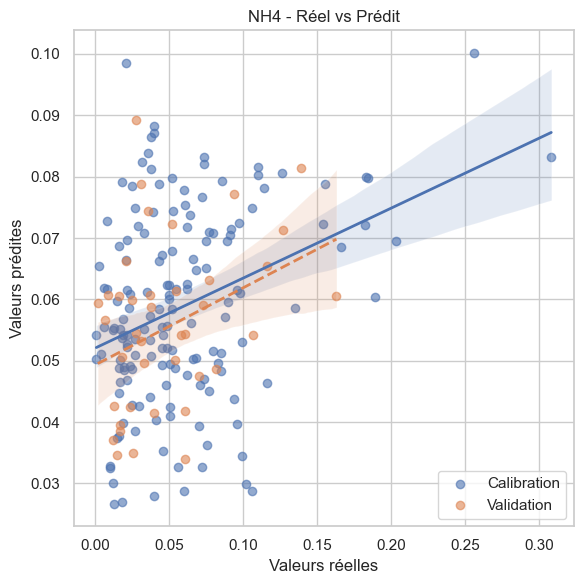

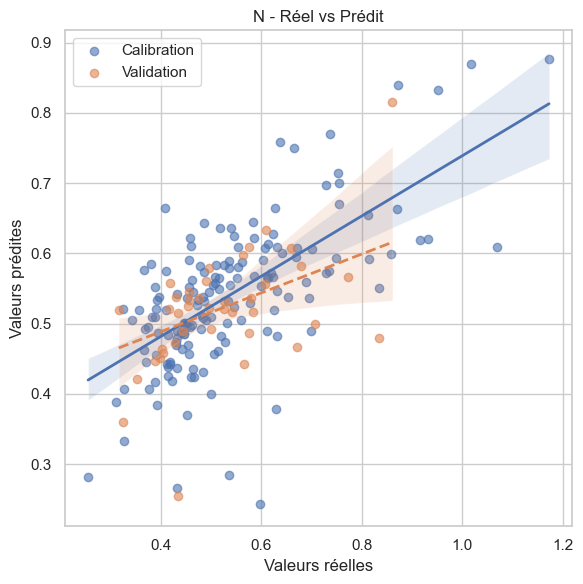

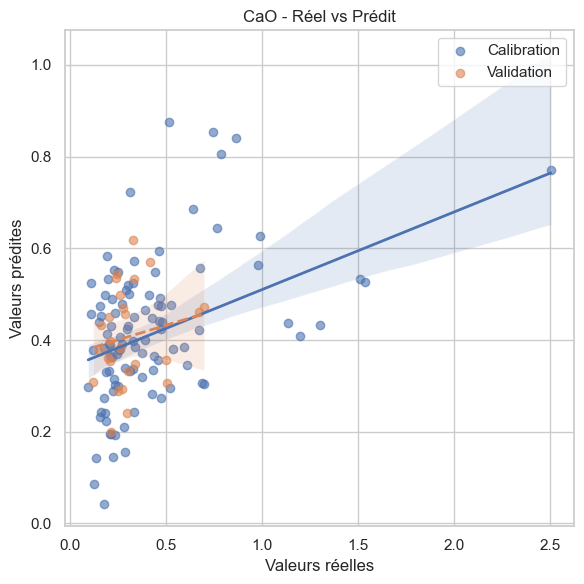

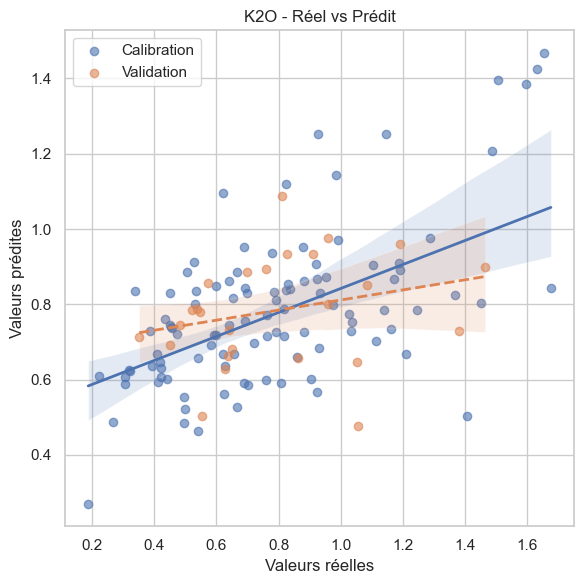

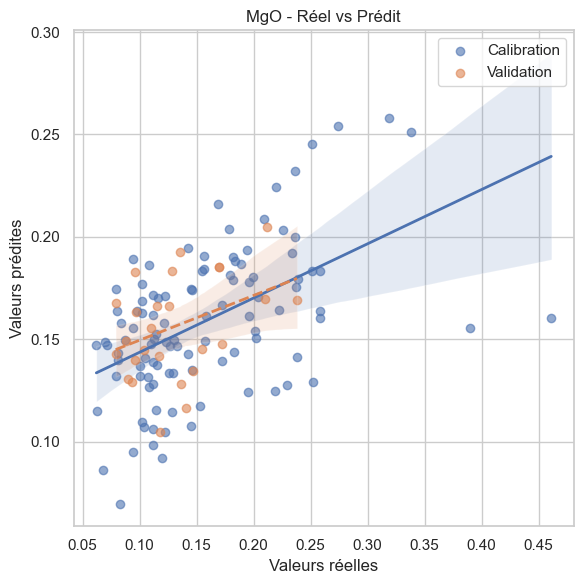

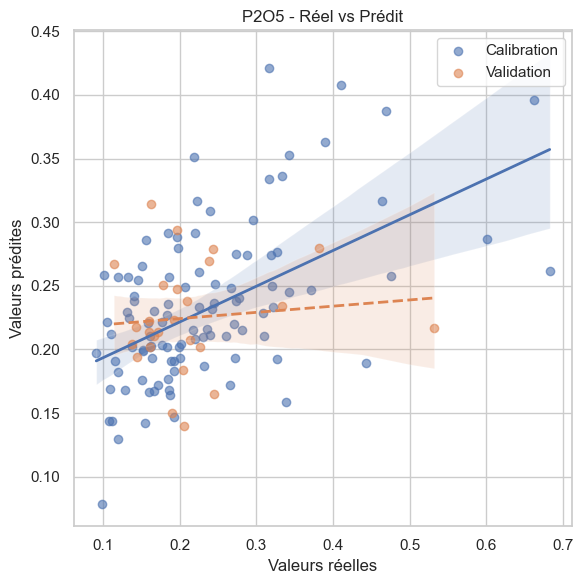

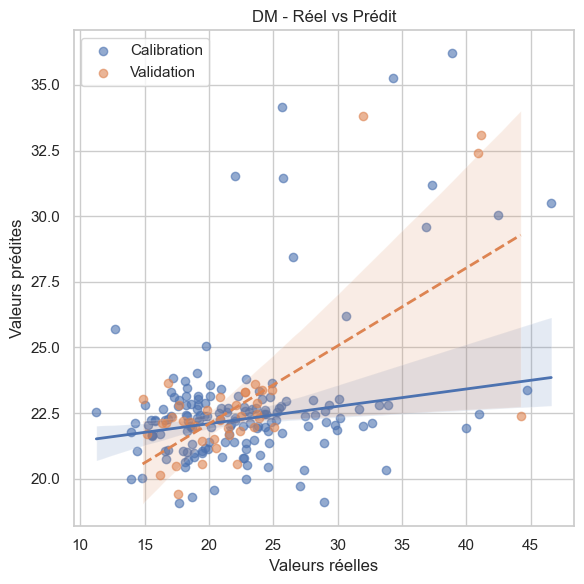

In [ ]:

for name in predictions:

    y_train = predictions[name]["y_train"]
    y_test = predictions[name]["y_test"]
    y_pred_train = predictions[name]["y_pred_train"]
    y_pred_test = predictions[name]["y_pred_test"]

    plt.figure(figsize=(6,6))

    # --- Calibration (train) ---
    sns.regplot(
        x=y_train,
        y=y_pred_train,
        robust=True,
        label="Calibration",
        scatter_kws={"alpha":0.6},
        line_kws={"linewidth":2}
    )

    # --- Validation (test) ---
    sns.regplot(
        x=y_test,
        y=y_pred_test,
        robust=True,
        label="Validation",
        scatter_kws={"alpha":0.6},
        line_kws={"color":"red", "linewidth":2}
    )


    plt.xlabel("Valeurs réelles")
    plt.ylabel("Valeurs prédites")
    plt.title(f"{name} - Réel vs Prédit")
    plt.legend()
    plt.tight_layout()
    plt.show()


A la vue de ses modèles de régressions on peut observer que les données  